# Problem Statement
Create a Recommender System to show personalized movie recommendations based on ratings given by a user and other users similar to them in order to improve user experience.

# Import Libs

In [1]:
!pip install optuna
!pip install cmfrec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 5.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached findblas-0.1.26.post1-py3-none-any.whl
  Created wheel for cmfrec: filename=cmfrec-3.5.1.post13-cp312-cp312-linux_x86_64.whl size=5947555 sha256=b11ab2d202a64c655e504d3dbbb9c37ee62cbfd35b3be6beb15e49a06312f121
  Stored in directory: /root/.cache/pip/wheels/46/9d/a7/03614a1633b40dde9aeb6eb12265f9c684feba1e3d82fe05bf
Successfully built cmfrec


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_percentage_error as mape
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import random
import umap
import optuna
from cmfrec import CMF

import ipywidgets as widgets
from IPython.display import display, clear_output

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Load Datasets

In [4]:
import gdown
folder_url = 'https://drive.google.com/drive/folders/1qe3di-dDXC4uMZp8dGIv-J_bFHoKjrWi'
gdown.download_folder(folder_url, quiet=False, remaining_ok=True)

Retrieving folder contents


Processing file 15QeQgmjoeBxRDEOFPSrMr8eIvwk6QgUQ zee-movies.dat
Processing file 1XJpSzv-UMeSmCCOdyZviRF4XCxiKJUrk zee-ratings.dat
Processing file 1-xsSNizet0ruiMgKLWRcmme8L_iDejhc zee-users.dat


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=15QeQgmjoeBxRDEOFPSrMr8eIvwk6QgUQ
To: /content/ZEE-data/zee-movies.dat
100%|██████████| 171k/171k [00:00<00:00, 50.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XJpSzv-UMeSmCCOdyZviRF4XCxiKJUrk
To: /content/ZEE-data/zee-ratings.dat
100%|██████████| 24.6M/24.6M [00:00<00:00, 40.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-xsSNizet0ruiMgKLWRcmme8L_iDejhc
To: /content/ZEE-data/zee-users.dat
100%|██████████| 134k/134k [00:00<00:00, 26.6MB/s]
Download completed


['/content/ZEE-data/zee-movies.dat',
 '/content/ZEE-data/zee-ratings.dat',
 '/content/ZEE-data/zee-users.dat']

In [5]:
movies = pd.read_csv(
    'ZEE-data/zee-movies.dat',
    sep='::',
    engine='python',
    encoding='ISO-8859-1'
)
movies.sample(5)

,Movie ID,Title,Genres
1344,1365,Ridicule (1996),Drama
2637,2706,American Pie (1999),Comedy
3598,3667,Rent-A-Cop (1988),Action|Comedy
3615,3684,"Fabulous Baker Boys, The (1989)",Drama|Romance
1812,1881,Quest for Camelot (1998),Adventure|Animation|Children's|Fantasy


In [6]:
ratings = pd.read_csv(
    'ZEE-data/zee-ratings.dat',
    sep='::',
    engine='python',
    encoding='ISO-8859-1'
)
ratings.sample(5)

,UserID,MovieID,Rating,Timestamp
844959,5077,2664,5,962566806
20665,151,1614,4,993119850
189300,1173,3453,2,974860447
997815,6026,924,5,956725858
782996,4675,302,3,963735201


In [7]:
users = pd.read_csv(
    'ZEE-data/zee-users.dat',
    sep='::',
    engine='python',
    encoding='ISO-8859-1'
)
users.sample(5)

,UserID,Gender,Age,Occupation,Zip-code
2324,2325,F,18,4,27708
3368,3369,M,45,18,14701
2430,2431,F,25,4,22903
4035,4036,M,25,1,46530
65,66,M,25,18,57706


# EDA

## `users` EDA

In [8]:
users.shape

(6040, 5)

In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   int64 
 3   Occupation  6040 non-null   int64 
 4   Zip-code    6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


In [10]:
users['Gender'].value_counts(normalize=True) * 100

,proportion
Gender,
M,71.705298
F,28.294702


In [11]:
age_map = {
    1: "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+"
}

users['Age_Label'] = users['Age'].map(age_map)
users['Age_Label'].value_counts(normalize=True) * 100

,proportion
Age_Label,
25-34,34.701987
35-44,19.751656
18-24,18.261589
45-49,9.105960
50-55,8.211921
56+,6.291391
Under 18,3.675497


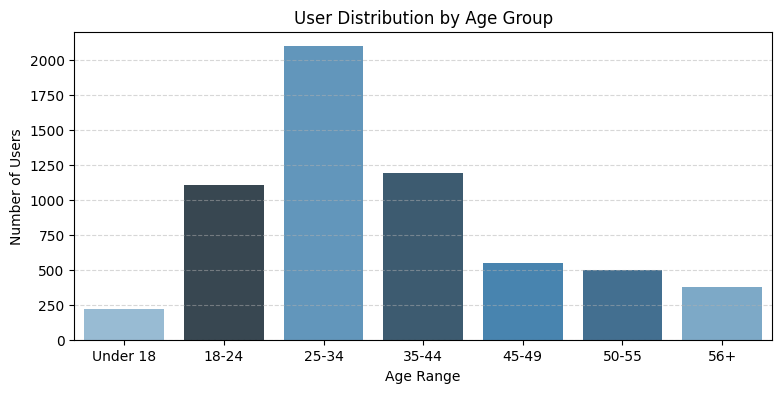

In [12]:
plt.figure(figsize=(9, 4))
sns.countplot(data=users, x='Age_Label', order=age_map.values(), palette='Blues_d', hue = 'Age_Label')
plt.title('User Distribution by Age Group')
plt.xlabel('Age Range')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [13]:
# Occupation map
occ_map = {
    0: "other", 1: "academic/educator", 2: "artist", 3: "clerical/admin",
    4: "college/grad student", 5: "customer service", 6: "doctor/health care",
    7: "executive/managerial", 8: "farmer", 9: "homemaker", 10: "K-12 student",
    11: "lawyer", 12: "programmer", 13: "retired", 14: "sales/marketing",
    15: "scientist", 16: "self-employed", 17: "technician/engineer",
    18: "tradesman/craftsman", 19: "unemployed", 20: "writer"
}

users['Occupation_Label'] = users['Occupation'].map(occ_map)
users['Occupation_Label'].value_counts(normalize=True).head(6) * 100

,proportion
Occupation_Label,
college/grad student,12.566225
other,11.771523
executive/managerial,11.241722
academic/educator,8.741722
technician/engineer,8.311258
programmer,6.423841


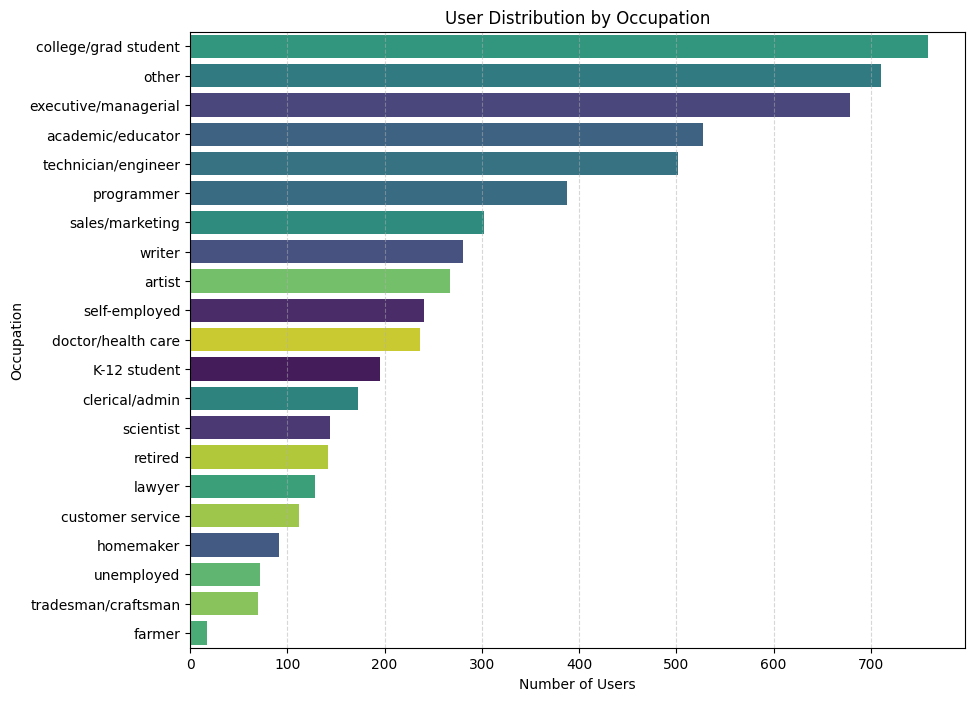

In [14]:
plt.figure(figsize=(10, 8))
sns.countplot(
    data=users,
    y='Occupation_Label',
    order=users['Occupation_Label'].value_counts().index,
    palette='viridis',
    hue='Occupation_Label'
)
plt.title('User Distribution by Occupation')
plt.xlabel('Number of Users')
plt.ylabel('Occupation')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [15]:
users['Zip-code'].nunique()

3439

In [16]:
users['Zip-code'].value_counts().head(5)

,count
Zip-code,
48104,19
22903,18
94110,17
55104,17
55105,16


## `movies` EDA

In [17]:
movies.shape

(3883, 3)

In [18]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Movie ID  3883 non-null   int64 
 1   Title     3883 non-null   object
 2   Genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [19]:
movies.sample(5)

,Movie ID,Title,Genres
843,854,"Ballad of Narayama, The (Narayama Bushiko) (1958)",Drama
3215,3284,They Might Be Giants (1971),Comedy|Romance
3718,3787,Shower (Xizhao) (1999),Comedy
1624,1670,Welcome To Sarajevo (1997),Drama|War
3817,3887,Went to Coney Island on a Mission From God... ...,Drama


In [20]:
movies['Release Year'] = movies['Title'].str.extract(r'\((\d{4})\)')
movies.sample(5)

,Movie ID,Title,Genres,Release Year
899,911,Charade (1963),Comedy|Mystery|Romance|Thriller,1963
2966,3035,Mister Roberts (1955),Comedy|Drama|War,1955
2391,2460,"Texas Chainsaw Massacre 2, The (1986)",Horror,1986
143,145,Bad Boys (1995),Action,1995
1761,1829,Chinese Box (1997),Drama|Romance,1997


In [21]:
movies['Release Year'] = movies['Release Year'].astype(int)
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Movie ID      3883 non-null   int64 
 1   Title         3883 non-null   object
 2   Genres        3883 non-null   object
 3   Release Year  3883 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 121.5+ KB


In [22]:
np.sort(movies['Release Year'].unique())

array([1919, 1920, 1921, 1922, 1923, 1925, 1926, 1927, 1928, 1929, 1930,
       1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941,
       1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952,
       1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963,
       1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974,
       1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985,
       1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996,
       1997, 1998, 1999, 2000])

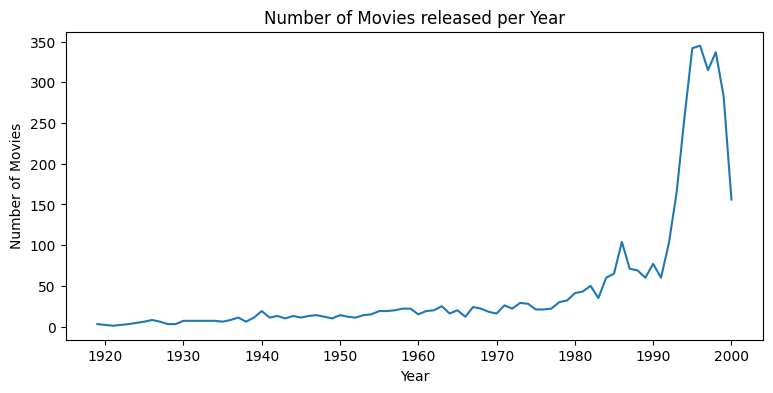

In [23]:
year_counts = movies['Release Year'].value_counts().sort_index()
plt.figure(figsize=(9, 4))
sns.lineplot(x=year_counts.index, y=year_counts.values)
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Number of Movies released per Year')
plt.show()

In [24]:
movies['Genres'] = movies['Genres'].str.split('|')
movies.sample(5)

,Movie ID,Title,Genres,Release Year
1370,1391,Mars Attacks! (1996),"[Action, Comedy, Sci-Fi, War]",1996
3842,3912,Beautiful (2000),"[Comedy, Drama]",2000
653,659,Purple Noon (1960),"[Crime, Thriller]",1960
1101,1117,"Eighth Day, The (Le Huitième jour ) (1996)",[Drama],1996
554,558,"Pagemaster, The (1994)","[Action, Adventure, Animation, Children's, Fan...",1994


In [25]:
movies = movies.explode('Genres')

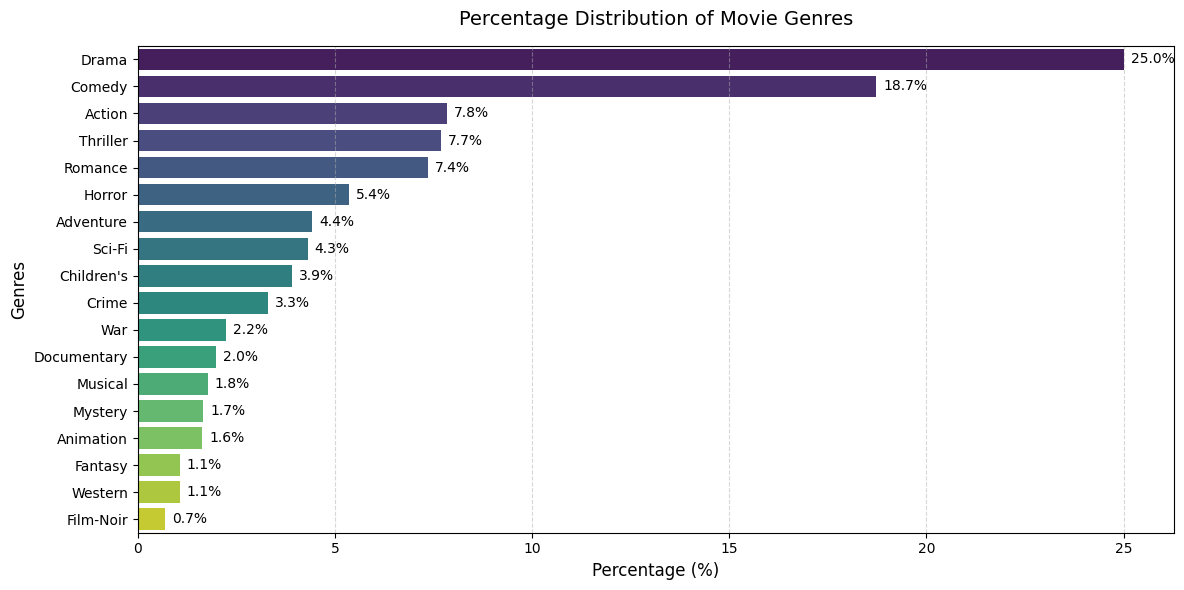

In [26]:
genre_pct = movies['Genres'].value_counts(normalize=True) * 100
plt.figure(figsize=(12, 6), dpi=100)
sns.barplot(
    x=genre_pct.values,
    y=genre_pct.index,
    palette='viridis',
    hue=genre_pct.index,
    legend=False
)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f%%', padding=5)

plt.title('Percentage Distribution of Movie Genres', fontsize=14, pad=15)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Genres', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## `ratings` EDA

In [27]:
ratings.shape

(1000209, 4)

In [28]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


- UserIDs range between 1 and 6040

- MovieIDs range between 1 and 3952

- Ratings are made on a 5-star scale (whole-star ratings only)

- Timestamp is represented in seconds

- Each user has at least 20 ratings

In [29]:
ratings['Rating'].value_counts(normalize=True) * 100

,proportion
Rating,
4,34.889808
3,26.114242
5,22.626271
2,10.753453
1,5.616226


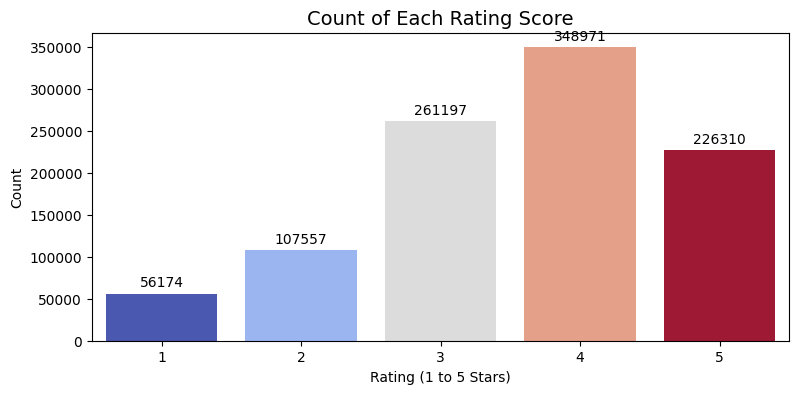

In [30]:
plt.figure(figsize=(9, 4))
sns.countplot(data=ratings, x='Rating', palette='coolwarm', hue='Rating', legend=False)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3)

plt.title('Count of Each Rating Score', fontsize=14)
plt.xlabel('Rating (1 to 5 Stars)')
plt.ylabel('Count')
plt.show()

In [31]:
ratings['MovieID'].value_counts().head(5)

,count
MovieID,
2858,3428
260,2991
1196,2990
1210,2883
480,2672


In [32]:
ratings['UserID'].value_counts().head(5)

,count
UserID,
4169,2314
1680,1850
4277,1743
1941,1595
1181,1521


In [33]:
# Convert Unix seconds into a clear Year-Month-Day datetime object
ratings['Timestamp'] = pd.to_datetime(ratings['Timestamp'], unit='s')
ratings.sample(5)

,UserID,MovieID,Rating,Timestamp
987053,5957,1748,3,2000-04-30 06:01:35
745884,4450,3704,2,2000-07-31 23:46:09
816951,4904,1320,5,2000-07-04 04:08:35
379087,2214,2908,4,2000-11-19 02:32:22
616713,3732,3703,4,2000-11-12 20:52:25


In [34]:
# Extract the Year of the rating
ratings['Rating_Year'] = ratings['Timestamp'].dt.year

# Extract the Month (1 to 12)
ratings['Rating_Month'] = ratings['Timestamp'].dt.month

# Extract Day of the Week (0 = Monday, 6 = Sunday)
ratings['Rating_Day'] = ratings['Timestamp'].dt.dayofweek

# Extract Hour of the Day (0 to 23) to see morning vs. night behavior
ratings['Rating_Hour'] = ratings['Timestamp'].dt.hour

In [35]:
ratings.sample(5)

,UserID,MovieID,Rating,Timestamp,Rating_Year,Rating_Month,Rating_Day,Rating_Hour
24231,173,922,5,2001-05-22 16:13:01,2001,5,1,16
784565,4682,172,4,2000-08-06 03:11:03,2000,8,6,3
42779,293,3363,3,2000-12-11 18:55:16,2000,12,0,18
628588,3807,258,2,2000-08-11 03:50:00,2000,8,4,3
886733,5358,589,3,2000-06-09 12:30:16,2000,6,4,12


In [36]:
ratings['Timestamp'].min(), ratings['Timestamp'].max()

(Timestamp('2000-04-25 23:05:32'), Timestamp('2003-02-28 17:49:50'))

In [37]:
ratings['Rating_Year'].value_counts(normalize=True) * 100

,proportion
Rating_Year,
2000,90.456795
2001,6.804378
2002,2.404098
2003,0.334730


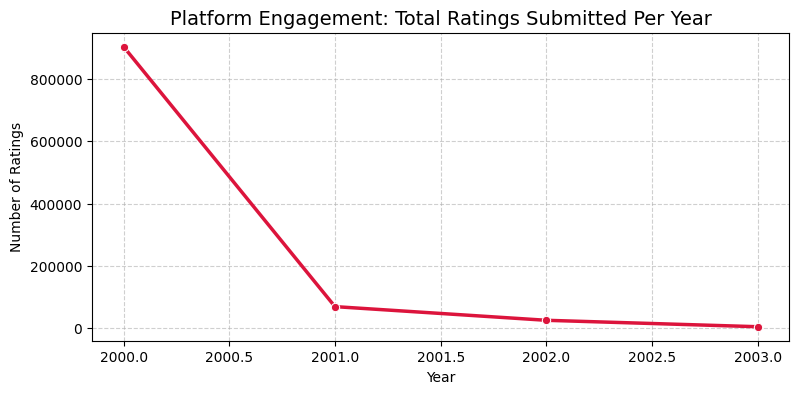

In [38]:
yearly_trends = ratings['Rating_Year'].value_counts().reset_index(name='Total_Ratings')

plt.figure(figsize=(9, 4))
sns.lineplot(data=yearly_trends, x='Rating_Year', y='Total_Ratings', marker='o', color='crimson', linewidth=2.5)
plt.title('Platform Engagement: Total Ratings Submitted Per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

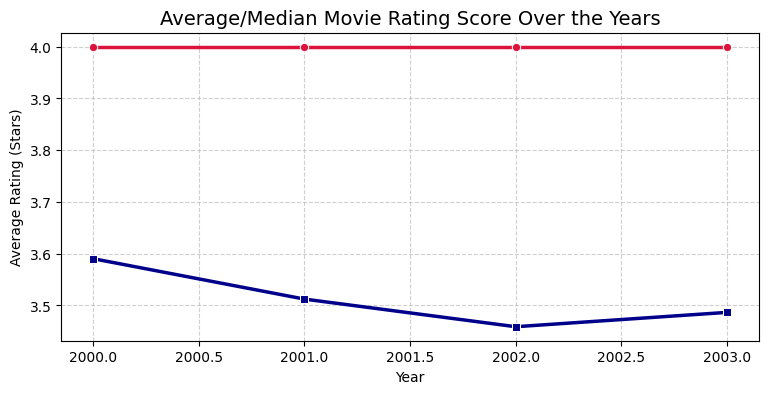

In [39]:
yearly_scores_mean = ratings.groupby('Rating_Year')['Rating'].mean().reset_index()
yearly_scores_median = ratings.groupby('Rating_Year')['Rating'].median().reset_index()
plt.figure(figsize=(9, 4))
sns.lineplot(data=yearly_scores_mean, x='Rating_Year', y='Rating', marker='s', color='darkblue', linewidth=2.5)
sns.lineplot(data=yearly_scores_median, x='Rating_Year', y='Rating', marker='o', color='crimson', linewidth=2.5)
plt.title('Average/Median Movie Rating Score Over the Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Rating (Stars)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

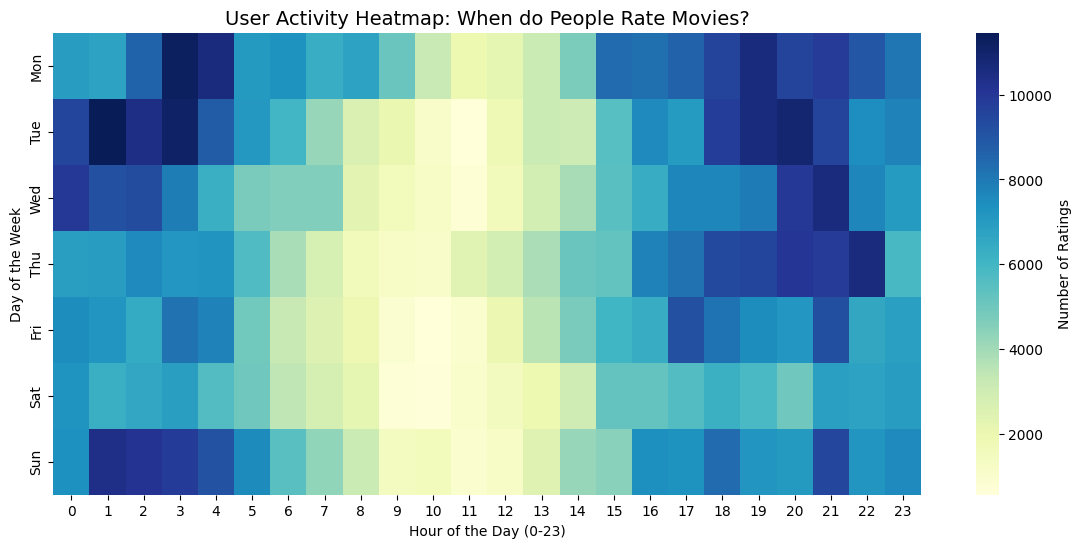

In [40]:
time_matrix = ratings.pivot_table(index='Rating_Day', columns='Rating_Hour', values='Rating', aggfunc='count').fillna(0)

plt.figure(figsize=(14, 6))
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.heatmap(time_matrix, cmap='YlGnBu', yticklabels=day_labels, cbar_kws={'label': 'Number of Ratings'})

plt.title('User Activity Heatmap: When do People Rate Movies?', fontsize=14)
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Day of the Week')
plt.show()

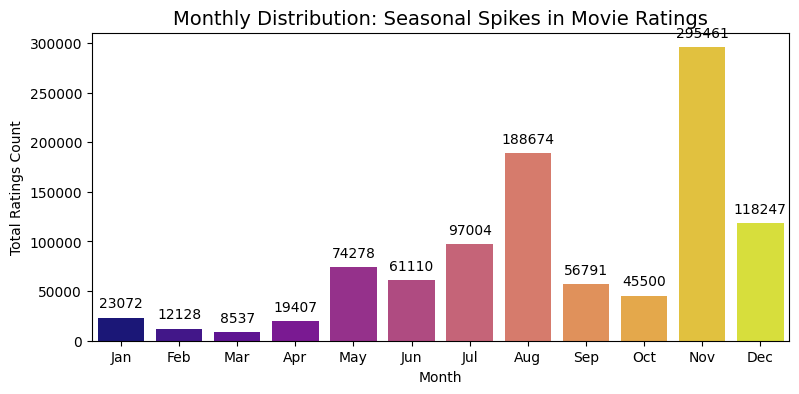

In [41]:
monthly_activity = ratings['Rating_Month'].value_counts().reset_index(name='Count')

plt.figure(figsize=(9, 4))
sns.barplot(data=monthly_activity, x='Rating_Month', y='Count', palette='plasma', hue='Rating_Month', legend=False)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f', padding=5)

plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Distribution: Seasonal Spikes in Movie Ratings', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Ratings Count')
plt.show()

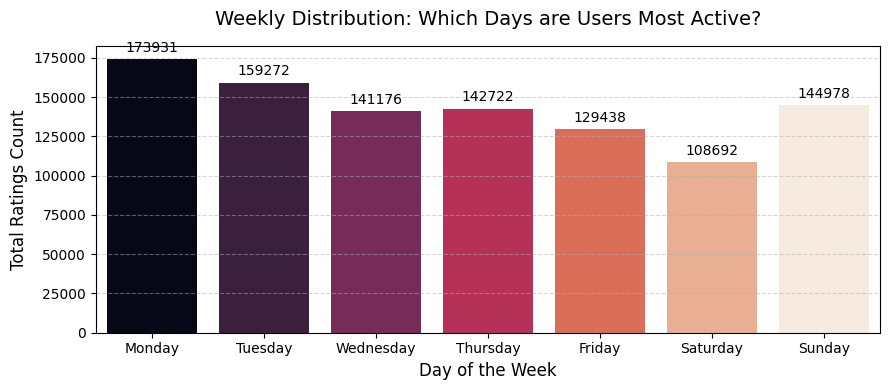

In [42]:
weekly_activity = ratings['Rating_Day'].value_counts().reset_index(name='Count')

plt.figure(figsize=(9, 4))
sns.barplot(
    data=weekly_activity,
    x='Rating_Day',
    y='Count',
    palette='rocket',
    hue='Rating_Day',
    legend=False
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3)

plt.xticks(
    ticks=range(7),
    labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
plt.title('Weekly Distribution: Which Days are Users Most Active?', fontsize=14, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Ratings Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

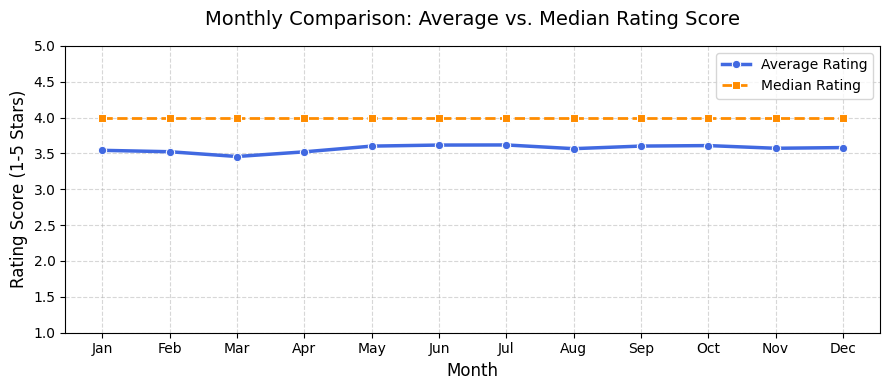

In [43]:
monthly_stats = ratings.groupby('Rating_Month')['Rating'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(9, 4))

sns.lineplot(
    data=monthly_stats, x='Rating_Month', y='mean',
    marker='o', color='royalblue', linewidth=2.5, label='Average Rating'
)

sns.lineplot(
    data=monthly_stats, x='Rating_Month', y='median',
    marker='s', color='darkorange', linewidth=2, linestyle='--', label='Median Rating'
)

plt.xticks(
    ticks=range(1, 13),
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
plt.title('Monthly Comparison: Average vs. Median Rating Score', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Rating Score (1-5 Stars)', fontsize=12)
plt.ylim(1, 5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

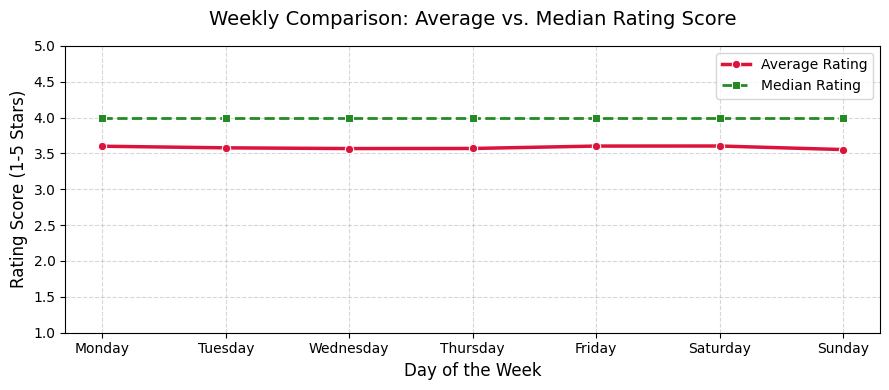

In [44]:
weekday_stats = ratings.groupby('Rating_Day')['Rating'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(9, 4))

sns.lineplot(
    data=weekday_stats, x='Rating_Day', y='mean',
    marker='o', color='crimson', linewidth=2.5, label='Average Rating'
)

sns.lineplot(
    data=weekday_stats, x='Rating_Day', y='median',
    marker='s', color='forestgreen', linewidth=2, linestyle='--', label='Median Rating'
)

plt.xticks(
    ticks=range(7),
    labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
plt.title('Weekly Comparison: Average vs. Median Rating Score', fontsize=14, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Rating Score (1-5 Stars)', fontsize=12)
plt.ylim(1, 5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## EDA on combined dataset

In [45]:
movies.info(), ratings.info(), users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6408 entries, 0 to 3882
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Movie ID      6408 non-null   int64 
 1   Title         6408 non-null   object
 2   Genres        6408 non-null   object
 3   Release Year  6408 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 250.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   UserID        1000209 non-null  int64         
 1   MovieID       1000209 non-null  int64         
 2   Rating        1000209 non-null  int64         
 3   Timestamp     1000209 non-null  datetime64[ns]
 4   Rating_Year   1000209 non-null  int32         
 5   Rating_Month  1000209 non-null  int32         
 6   Rating_Day    1000209 non-null  int32         
 7   Rating_Hou

(None, None, None)

In [46]:
movie_ratings = pd.merge(
    ratings,
    movies,
    left_on='MovieID',
    right_on='Movie ID',
    how='inner'
)

movie_summary = movie_ratings.groupby('Title')['Rating'].agg(
    Avg_Rating='mean',
    Num_of_Ratings='count'
).reset_index()

In [47]:
top_10_movies = movie_summary.sort_values(by='Num_of_Ratings', ascending=False).head(10)
top_10_movies

,Title,Avg_Rating,Num_of_Ratings
3154,Star Wars: Episode V - The Empire Strikes Back...,4.292977,14950
3155,Star Wars: Episode VI - Return of the Jedi (1983),4.022893,14415
3153,Star Wars: Episode IV - A New Hope (1977),4.453694,11964
2141,Men in Black (1997),3.739953,10152
2654,"Princess Bride, The (1987)",4.303710,9272
1860,L.A. Confidential (1997),4.219406,9152
1007,E.T. the Extra-Terrestrial (1982),3.965183,9076
3152,Star Wars: Episode I - The Phantom Menace (1999),3.409778,9000
98,Alien (1979),4.159585,8096
1789,Jurassic Park (1993),3.763847,8016


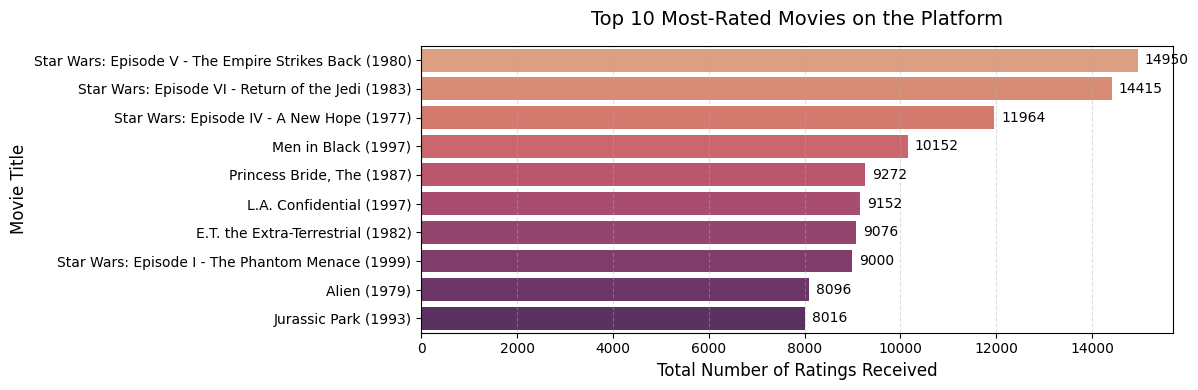

In [48]:
plt.figure(figsize=(12, 4))

sns.barplot(
    data=top_10_movies,
    x='Num_of_Ratings',
    y='Title',
    palette='flare',
    hue='Title',
    legend=False
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=5)

plt.title('Top 10 Most-Rated Movies on the Platform', fontsize=14, pad=15)
plt.xlabel('Total Number of Ratings Received', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

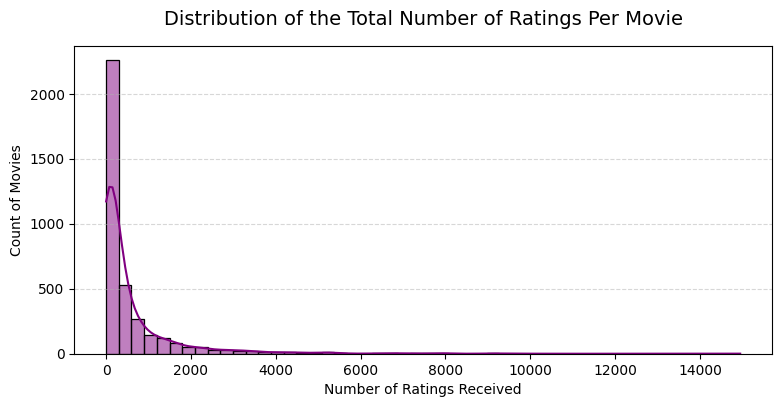

In [49]:
plt.figure(figsize=(9, 4))
sns.histplot(data=movie_summary, x='Num_of_Ratings', bins=50, kde=True, color='purple')

plt.title('Distribution of the Total Number of Ratings Per Movie', fontsize=14, pad=15)
plt.xlabel('Number of Ratings Received')
plt.ylabel('Count of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

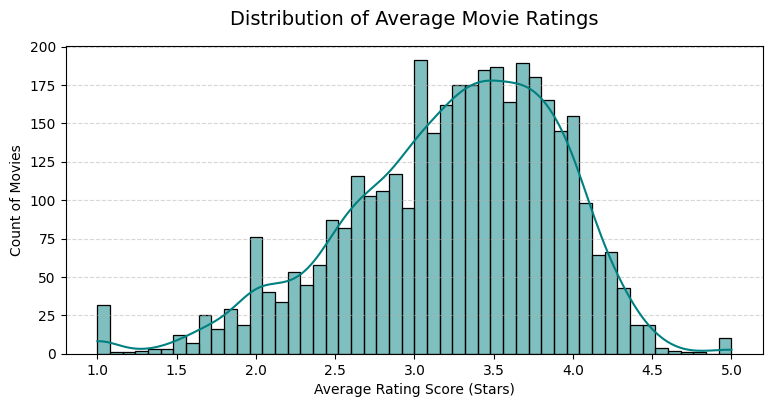

In [50]:
plt.figure(figsize=(9, 4))

sns.histplot(data=movie_summary, x='Avg_Rating', bins=50, kde=True, color='teal')

plt.title('Distribution of Average Movie Ratings', fontsize=14, pad=15)
plt.xlabel('Average Rating Score (Stars)')
plt.ylabel('Count of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

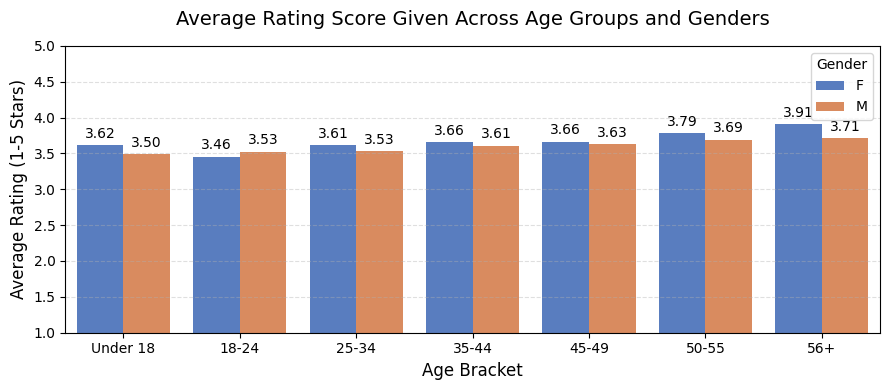

In [51]:
master_df = pd.merge(movie_ratings, users, on='UserID', how='inner')
demographic_ratings = master_df.groupby(['Age_Label', 'Gender'])['Rating'].mean().reset_index()

plt.figure(figsize=(9, 4))

sns.barplot(
    data=demographic_ratings,
    x='Age_Label',
    y='Rating',
    hue='Gender',
    palette='muted',
    order=["Under 18", "18-24", "25-34", "35-44", "45-49", "50-55", "56+"]
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', padding=3)

plt.title('Average Rating Score Given Across Age Groups and Genders', fontsize=14, pad=15)
plt.xlabel('Age Bracket', fontsize=12)
plt.ylabel('Average Rating (1-5 Stars)', fontsize=12)
plt.ylim(1, 5)
plt.legend(title='Gender', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

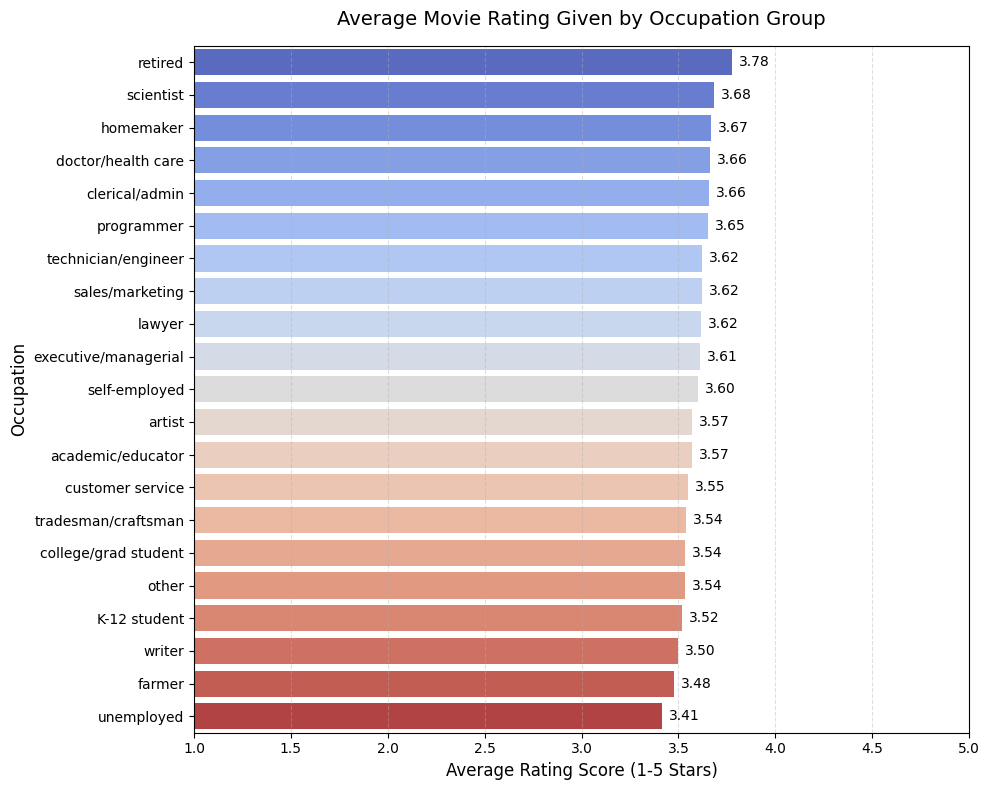

In [52]:
occ_ratings = master_df.groupby('Occupation_Label')['Rating'].mean().reset_index()
occ_ratings = occ_ratings.sort_values(by='Rating', ascending=False)

plt.figure(figsize=(10, 8), dpi=100)
sns.barplot(
    data=occ_ratings,
    x='Rating',
    y='Occupation_Label',
    palette='coolwarm',
    hue='Occupation_Label',
    legend=False
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', padding=5)

plt.title('Average Movie Rating Given by Occupation Group', fontsize=14, pad=15)
plt.xlabel('Average Rating Score (1-5 Stars)', fontsize=12)
plt.ylabel('Occupation', fontsize=12)
plt.xlim(1, 5)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


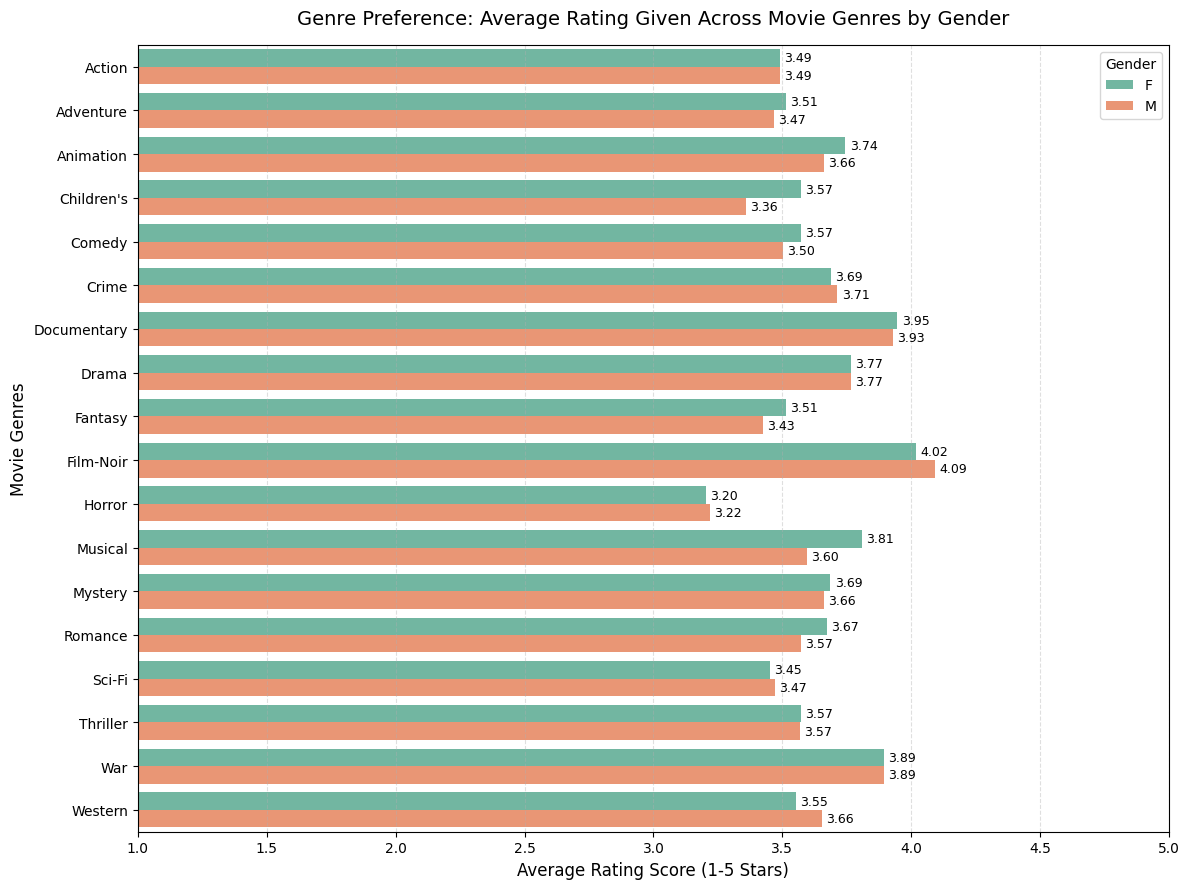

In [53]:
genre_gender_ratings = master_df.groupby(['Genres', 'Gender'])['Rating'].mean().reset_index()

genre_gender_ratings = genre_gender_ratings.sort_values(by='Genres')

plt.figure(figsize=(12, 9), dpi=100)

sns.barplot(
    data=genre_gender_ratings,
    y='Genres',
    x='Rating',
    hue='Gender',
    palette='Set2'
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.title('Genre Preference: Average Rating Given Across Movie Genres by Gender', fontsize=14, pad=15)
plt.xlabel('Average Rating Score (1-5 Stars)', fontsize=12)
plt.ylabel('Movie Genres', fontsize=12)
plt.xlim(1, 5)
plt.legend(title='Gender', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# Recommender System based on Pearson Correlation

In [54]:
# Rename 'Movie ID' to 'MovieID' to match the ratings DataFrame
movies = movies.rename(columns={'Movie ID': 'MovieID'})

# Merge and pivot without running .fillna(0) to avoid 0-imputation bias
user_movie_pivot = pd.merge(
    ratings[['UserID', 'MovieID', 'Rating']],
    movies[['MovieID', 'Title']],
    on='MovieID'
).pivot_table(
    index='Title',
    columns='UserID',
    values='Rating'
)

print(f"Matrix Shape: {user_movie_pivot.shape}")
print(f"Total missing values kept as NaN: {user_movie_pivot.isna().sum().sum()}")
print(f"Sparsity of user_movie_pivot", user_movie_pivot.isnull().sum().sum() / user_movie_pivot.size)

Matrix Shape: (3706, 6040)
Total missing values kept as NaN: 21384031
Sparsity of user_movie_pivot 0.9553163743776871


Why not imputing NaN with 0?

The algorithm treats those 0 rating as if users actively hated the film, warping the correlation matrix with noise from people who never engaged with the content.
As the matrix is sparse in nature, it will significantly affect recommendation.

In [55]:
print("\nCalculating fast pure Pearson matrix (Keeping NaNs)...")

# 1. Isolate the underlying matrix values array layout
matrix_values = user_movie_pivot.values

# 2. Compute the true movie averages while strictly ignoring NaNs
movie_means = np.nanmean(matrix_values, axis=1, keepdims=True)

# 3. Center the data vectors (Real ratings get centered, unwatched values stay NaN)
mean_centered_raw = matrix_values - movie_means

# 4. Generate a logical truth mask to map where real user ratings exist
rated_mask = ~np.isnan(matrix_values)

# 5. Swap NaNs to 0.0 inside a localized cache ONLY for the matrix multiplication step
mean_centered = np.nan_to_num(mean_centered_raw, nan=0.0)

# 6. Compute Covariance Matrix mapping (The Numerator)
covariance = np.dot(mean_centered, mean_centered.T)

# 7. Compute Variances over specific intersection coordinates (The Denominator)
squared_centered = mean_centered ** 2
sum_sq_X_supported_by_Y = np.dot(squared_centered, rated_mask.T)
denominator = np.sqrt(sum_sq_X_supported_by_Y * sum_sq_X_supported_by_Y.T)

# 8. Complete safe division calculation matrix rules
with np.errstate(divide='ignore', invalid='ignore'):
    pure_pearson_array = np.true_divide(covariance, denominator)
    np.fill_diagonal(pure_pearson_array, 1.0) # Ensure self-correlation matches exactly 1.0
    pure_pearson_array[~np.isfinite(pure_pearson_array)] = 0 # Convert invalid division fields to 0

# 9. Pre-calculate global shared user co-rater counts matrix to use in queries
shared_user_matrix = np.dot(rated_mask.astype(int), rated_mask.T.astype(int))

# 10. Wrap the array back into a queryable Pandas DataFrame structure
pearson_matrix = pd.DataFrame(
    pure_pearson_array,
    index=user_movie_pivot.index,
    columns=user_movie_pivot.index
)
print("Pure, Unbiased Pearson Matrix generated successfully!")


Calculating fast pure Pearson matrix (Keeping NaNs)...
Pure, Unbiased Pearson Matrix generated successfully!


In [56]:
pearson_matrix.head()

Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck (1971)",1.000000,0.176343,0.358979,0.002526,0.330712,0.0,-0.449871,0.522179,0.207973,-0.294098,...,0.525544,-0.176127,0.000000,-0.368718,0.0,-0.801515,0.041997,0.0,0.088942,-0.701909
'Night Mother (1986),0.176343,1.000000,-0.214010,0.153520,0.221334,0.0,0.285835,0.336940,-0.141042,0.257901,...,0.743289,-0.259618,-0.002564,-0.050167,0.0,-0.441209,0.073096,0.0,0.000000,0.043118
'Til There Was You (1997),0.358979,-0.214010,1.000000,0.715197,0.667764,-1.0,0.275247,0.461368,0.558256,0.239414,...,-0.358979,0.040533,0.000000,0.021637,0.0,-1.000000,0.205830,0.0,0.948058,0.310136
"'burbs, The (1989)",0.002526,0.153520,0.715197,1.000000,0.041864,0.0,0.187599,0.093870,0.123800,0.045238,...,0.349023,0.283615,-1.000000,0.172813,0.0,0.047099,0.049572,0.0,-0.377272,0.151926
...And Justice for All (1979),0.330712,0.221334,0.667764,0.041864,1.000000,0.0,0.277510,0.171123,-0.141700,0.299326,...,-0.288144,0.061556,0.593083,0.115550,0.0,-0.522509,0.199825,1.0,0.000000,-0.033118


Pearson correlation only looks at users who rated both movies. If a rare indie movie was watched by only one person, and that person also loved Toy Story, the math calculates a perfect 1.0 correlation. This statistical noise causes random, obscure movies to ruin top recommendations.

That's why a co-rater requirement is essential to eliminate high-correlation noise caused by low sample sizes. Without it, obscure items with only one or two shared ratings can accidentally achieve a perfect 1.0 Pearson Correlation due to pure statistical coincidence. Forcing a minimum co-rater threshold ensures that a correlation score is only trusted if it is backed by a statistically significant volume of shared human behavior.


In [57]:
def recommend_movies_pearson(movie_title, corr_matrix, pivot_df, shared_counts_matrix, top_n=5):
    """
    Recommends top N similar movies dynamically neutralizing Small-Sample Noise Bias.
    """
    # 1. Validation check ensuring title sequence alignment matches
    if movie_title not in corr_matrix.index:
        print(f"Error: '{movie_title}' was not found in the dataset index.")
        return None

    # 2. Extract total number of valid user reviews for the input title (.count() ignores NaNs)
    total_movie_ratings = pivot_df.loc[movie_title].count()

    # 3. Compute a dynamic threshold limit proportional to popularity (10% of total ratings, floor of 5)
    dynamic_threshold = max(5, int(total_movie_ratings * 0.10))

    print("-" * 60)
    print(f"TARGET MOVIE: {movie_title} (Total Ratings Count: {total_movie_ratings})")
    print(f"DYNAMIC FILTER: Eliminating records with less than {dynamic_threshold} co-raters.")
    print("-" * 60)

    # 4. Extract target movie row index positions out of the tracking arrays
    movie_idx = pivot_df.index.get_loc(movie_title)
    specific_movie_shared_counts = shared_counts_matrix[movie_idx]

    # 5. Extract target correlation row slice vector
    movie_corr = corr_matrix[movie_title].copy()

    # 6. Apply Dynamic Threshold: Zero-out correlation vectors failing to pass user intersections
    movie_corr[specific_movie_shared_counts < dynamic_threshold] = 0

    # 7. Package vectors into final presentable Pandas Dataframe formatting
    recommendations = pd.DataFrame(movie_corr)
    recommendations.columns = ['Pearson_Correlation']
    recommendations = recommendations.drop(labels=[movie_title], errors='ignore') # Drop self

    # 8. Sort and isolate top matches
    top_recommendations = recommendations.sort_values(by='Pearson_Correlation', ascending=False).head(top_n)

    return top_recommendations.reset_index()

## Interactive Pearson-Movie-Recomendation system

In [58]:
# 1. Gather all unique movie names alphabetically from  pivot table
all_movie_titles = sorted(user_movie_pivot.index.tolist())

# 2. Create the interactive dropdown widget using ipywidgets
movie_dropdown = widgets.Dropdown(
    options=all_movie_titles,
    value='Toy Story 2 (1999)',  # Set default starting movie
    description='Select Movie:',
    disabled=False,
    layout={'width': 'max-content'} # Adjusts width to fit long movie titles perfectly
)

# 3. Create a slider for adjusting the number of recommendations
recs_slider = widgets.IntSlider(
    value=5, min=1, max=20, step=1,
    description='Count:'
)

# 4. Define an execution container that handles updates instantly
def on_change(change):
    clear_output(wait=True) # Clears the old table when you pick a new movie
    display(widgets.VBox([movie_dropdown, recs_slider])) # Keeps the dropdown menu visible

    print("\n" + "="*60)
    print("             GENERATING RECOMMENDATIONS               ")
    print("="*60)

    # Run  dynamic Pearson recommendation function pipeline
    results = recommend_movies_pearson(
        movie_title=movie_dropdown.value,
        corr_matrix=pearson_matrix,
        pivot_df=user_movie_pivot,
        shared_counts_matrix=shared_user_matrix,
        top_n=recs_slider.value
    )

    if results is not None:
        print("\n TOP RECOMMENDATIONS FOUND: \n")
        print(results.to_string(index=False))
    print("="*60)

# 5. Link the widgets to the execution container function
movie_dropdown.observe(on_change, names='value')
recs_slider.observe(on_change, names='value')

# 6. Initial display launch
display(widgets.VBox([movie_dropdown, recs_slider]))
on_change(None)


             GENERATING RECOMMENDATIONS               
------------------------------------------------------------
TARGET MOVIE: Toy Story 2 (1999) (Total Ratings Count: 1585)
DYNAMIC FILTER: Eliminating records with less than 158 co-raters.
------------------------------------------------------------

 TOP RECOMMENDATIONS FOUND: 

               Title  Pearson_Correlation
    Toy Story (1995)             0.622415
     Hercules (1997)             0.449161
Bug's Life, A (1998)             0.446487
Rescuers, The (1977)             0.409066
      Aladdin (1992)             0.387346


# Recommender System based on Nearest Neighbour using Cosine Similarity

In [59]:
user_movie_pivot.sample(5)

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
Title,,,,,,,,,,,,,,,,,,,,,
Love Walked In (1998),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Beautiful Thing (1996),NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arguing the World (1996),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Firestorm (1998),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monument Ave. (1998),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
user_movie_pivot_im = user_movie_pivot.fillna(0)
user_movie_pivot_im.sample(5)

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
Title,,,,,,,,,,,,,,,,,,,,,
To Kill a Mockingbird (1962),4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,5.0,0.0,0.0,0.0
Mary Shelley's Frankenstein (1994),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Head On (1998),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dudley Do-Right (1999),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
"Stars Fell on Henrietta, The (1995)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
movie_similarity = cosine_similarity(user_movie_pivot_im)
movie_similarity_df = pd.DataFrame(movie_similarity, index=user_movie_pivot_im.index, columns=user_movie_pivot_im.index)
movie_similarity_df.sample(5)

Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
Title,,,,,,,,,,,,,,,,,,,,,
"Right Stuff, The (1983)",0.054310,0.143559,0.056266,0.160066,0.202593,0.0,0.137733,0.214238,0.127510,0.329643,...,0.113674,0.216608,0.057743,0.122562,0.0,0.084943,0.166268,0.035090,0.073820,0.140773
"Phantom, The (1996)",0.069770,0.020407,0.036534,0.119639,0.097963,0.0,0.111870,0.155941,0.115754,0.090491,...,0.034862,0.216253,0.032788,0.067706,0.0,0.025240,0.161083,0.000000,0.027567,0.106763
Jack (1996),0.132509,0.106282,0.124895,0.207547,0.052127,0.0,0.165131,0.189368,0.242347,0.103437,...,0.036754,0.109900,0.021893,0.062455,0.0,0.025279,0.094673,0.000000,0.055220,0.085428
Queen Margot (La Reine Margot) (1994),0.058924,0.120028,0.121654,0.053117,0.068266,0.0,0.109082,0.100879,0.066130,0.059643,...,0.044829,0.101256,0.029669,0.106291,0.0,0.034259,0.092572,0.000000,0.024945,0.092696
Mission: Impossible 2 (2000),0.062183,0.064544,0.070411,0.184044,0.141848,0.0,0.296452,0.203434,0.164240,0.170957,...,0.061490,0.199611,0.046335,0.100565,0.0,0.050531,0.187690,0.032627,0.042667,0.216756


In [62]:
user_similarity = cosine_similarity(user_movie_pivot_im.T)
user_similarity_df = pd.DataFrame(user_similarity, index=user_movie_pivot_im.columns, columns=user_movie_pivot_im.columns)
user_similarity_df.sample(5)

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
UserID,,,,,,,,,,,,,,,,,,,,,
3249,0.155699,0.154320,0.223607,0.151809,0.155360,0.064029,0.041471,0.122322,0.201709,0.193783,...,0.113763,0.120936,0.124031,0.059213,0.104735,0.189453,0.269841,0.064483,0.143152,0.221065
2576,0.119145,0.183143,0.191549,0.216235,0.118116,0.063979,0.273123,0.184988,0.172601,0.290982,...,0.147227,0.070895,0.252941,0.018942,0.241592,0.287665,0.142291,0.066009,0.072854,0.160295
5491,0.141703,0.245365,0.197903,0.102733,0.219277,0.091883,0.195645,0.255007,0.293377,0.257671,...,0.177153,0.083636,0.158408,0.040598,0.292313,0.293636,0.194032,0.062717,0.100431,0.216711
164,0.051611,0.070980,0.000000,0.100643,0.039534,0.067211,0.000000,0.011288,0.079856,0.141137,...,0.063057,0.025491,0.052077,0.000000,0.030721,0.075636,0.094620,0.080221,0.134581,0.101860
4750,0.282678,0.128281,0.195034,0.107162,0.146662,0.167629,0.113794,0.129702,0.220218,0.326582,...,0.190739,0.155354,0.121173,0.009522,0.170044,0.274650,0.164489,0.110612,0.170916,0.195311


In [63]:
# Compress into a Sparse Matrix layout to safeguard Colab RAM limits
sparse_items = csr_matrix(user_movie_pivot_im.values)

# Item-to-Item Similarity Matrix (Shape: Movies x Movies)
item_sim_array = cosine_similarity(sparse_items)
movie_similarity_df = pd.DataFrame(
    item_sim_array,
    index=user_movie_pivot_im.index,
    columns=user_movie_pivot_im.index
)

# User-to-User Similarity Matrix (Shape: Users x Users)
# Transposing the sparse matrix switches rows to Users, allowing user comparisons
user_sim_array = cosine_similarity(sparse_items.T)
user_similarity_df = pd.DataFrame(
    user_sim_array,
    index=user_movie_pivot_im.columns,
    columns=user_movie_pivot_im.columns
)

`user_similarity_df` and `movie_similarity_df` is same matrix that calculated above, this time it is calculated using csr_matrix.

`csr_matrix` is standard practice to safeguard memory and optimize calculation speeds. Both approch give exactly same results


In [64]:
# Initialize the KNN model using Cosine distance metric, algorithm='brute', Best for sparse user-item matrices and cosine similarity
model_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=5)
model_knn.fit(sparse_items)

NearestNeighbors(algorithm='brute', metric='cosine')

In [65]:
def recommend_knn_cosine(movie_title, pivot_df, model, top_n=5):
    """
    Finds top N nearest neighbor movies using a fitted KNN model and Cosine Distance.
    """
    if movie_title not in pivot_df.index:
        print(f"Error: '{movie_title}' was not found in the dataset index.")
        return None

    # 1. Find the numerical row index coordinate of the movie
    movie_idx = pivot_df.index.get_loc(movie_title)

    # 2. Reshape the single target movie vector for prediction rules
    movie_vector = pivot_df.iloc[movie_idx, :].values.reshape(1, -1)

    # 3. Query the trained model for distances and index positions
    # (top_n + 1 handles dropping the movie itself)
    distances, indices = model.kneighbors(movie_vector, n_neighbors=top_n + 1)

    # 4. Flatten the output arrays
    raw_indices = indices.flatten()
    raw_distances = distances.flatten()

    # 5. Extract titles and map distances back to similarity scores (Similarity = 1 - Distance)
    recommendation_list = []
    for i in range(len(raw_indices)):
        title = pivot_df.index[raw_indices[i]]
        if title == movie_title:
            continue # Skip self-matching

        similarity_score = 1 - raw_distances[i]
        recommendation_list.append({'Title': title, 'Cosine_Similarity': similarity_score})

    # 6. Package and output the data frame layout
    results_df = pd.DataFrame(recommendation_list).head(top_n)
    return results_df

## Interactive Movie-Recomendation system based on NN using cosine similarity

In [66]:
# 1. Extract all unique movie titles alphabetically from  filled pivot index
all_knn_titles = sorted(user_movie_pivot_im.index.tolist())

# 2. Build the interactive Dropdown Widget
knn_movie_dropdown = widgets.Dropdown(
    options=all_knn_titles,
    value='Toy Story 2 (1999)',  # Baseline default selection
    description='Movie Title:',
    disabled=False,
    layout={'width': 'max-content'} # Adjusts dynamically for long names
)

# 3. Build the recommendation quantity slider
knn_recs_slider = widgets.IntSlider(
    value=5, min=1, max=20, step=1,
    description='Count:'
)

# 4. Define the localized update engine
def trigger_knn_update(change):
    clear_output(wait=True) # Wipes old text prints to keep dashboard perfectly clean
    display(widgets.VBox([knn_movie_dropdown, knn_recs_slider])) # Holds menu layout static

    print("\n" + "="*60)
    print("         KNN COSINE NEAREST NEIGHBORS RECOMMENDATIONS       ")
    print("="*60)

    # Executes  exact code query function
    knn_results = recommend_knn_cosine(
        movie_title=knn_movie_dropdown.value,
        pivot_df=user_movie_pivot_im,
        model=model_knn,
        top_n=knn_recs_slider.value
    )

    if knn_results is not None:
        print(f"\nTOP {knn_recs_slider.value} NEIGHBORS FOUND FOR: {knn_movie_dropdown.value}\n")
        print(knn_results.to_string(index=False))
    print("="*60)

# 5. Attach listeners to watch for user input alterations
knn_movie_dropdown.observe(trigger_knn_update, names='value')
knn_recs_slider.observe(trigger_knn_update, names='value')

# 6. Initialize dashboard display instantly
display(widgets.VBox([knn_movie_dropdown, knn_recs_slider]))
trigger_knn_update(None)


         KNN COSINE NEAREST NEIGHBORS RECOMMENDATIONS       

TOP 5 NEIGHBORS FOUND FOR: Toy Story 2 (1999)

                     Title  Cosine_Similarity
          Toy Story (1995)           0.633104
      Bug's Life, A (1998)           0.565496
               Babe (1995)           0.484732
      Groundhog Day (1993)           0.480313
Shakespeare in Love (1998)           0.475330


    Title                           Pearson_Correlation
    Toy Story (1995)                0.622415
    Hercules (1997)                 0.449161
    Bug's Life, A (1998)            0.446487
    Rescuers, The (1977)            0.409066
    Aladdin (1992)                  0.387346
This the result of prev rec sys using pearson for `Toy Story 2 (1999)`

Pearson and Cosine yield different recommendations because Cosine Similarity operates on raw vectors where the 0-imputed unwatched movies act as a heavy geometric penalty, forcing the model to favour highly popular blockbuster titles. Pearson Correlation, however, implements mean-centering which neutralises individual user grading scales and ignores unrated gaps entirely. This allows Pearson to capture true relative sentiment (Can occasionally favour high-quality niche/indie films), while Cosine captures global co-occurrence and popularity (Heavily favours blockbusters (Popularity Bias)).

# Recommender System based on Matrix Factorization

In [67]:
ratings_src = ratings[['UserID', 'MovieID', 'Rating', 'Timestamp', 'Rating_Month', 'Rating_Day', 'Rating_Hour']].copy()
ratings_src.rename(columns={'UserID': 'UserId', 'MovieID': 'ItemId'}, inplace=True)

# Build User Side Matrix
users_clean = users.copy()
users_clean['Age'] = users_clean['Age'].astype(str)

user_demographics = pd.get_dummies(
    users_clean[['UserID', 'Gender', 'Age', 'Occupation_Label']],
    columns=['Gender', 'Age', 'Occupation_Label'],
    drop_first=True
).astype(float).set_index('UserID')

# Apply Time Transformations: Cyclical for Hour, Linear Scaling for Month & Day
ratings_src['hour_sin'] = np.sin(2 * np.pi * ratings_src['Rating_Hour'] / 24.0)
ratings_src['hour_cos'] = np.cos(2 * np.pi * ratings_src['Rating_Hour'] / 24.0)

# Extract user-level timeline profiles
user_time_context = ratings_src.groupby('UserId')[['Rating_Month', 'Rating_Day', 'hour_sin', 'hour_cos']].mean()

# LINEAR SCALING ONLY for Month (1-12) and Day (0-6) into a stable 0.0 to 1.0 range
user_time_context['Avg_Rating_Month'] = (user_time_context['Rating_Month'] - 1) / 11.0
user_time_context['Avg_Rating_Day'] = user_time_context['Rating_Day'] / 6.0

# Rename and drop old columns
user_time_context = user_time_context.rename(columns={
    'hour_sin': 'Avg_Hour_Sin',
    'hour_cos': 'Avg_Hour_Cos'
}).drop(columns=['Rating_Month', 'Rating_Day'])

# Merge user demographic profiles with the updated time-context matrix
user_side = user_demographics.join(user_time_context).fillna(0.0)

# Build Item Side Matrix
genre_dummies = pd.get_dummies(movies['Genres']).astype(int)
movie_features = pd.concat([movies[['MovieID', 'Release Year']], genre_dummies], axis=1)

# Group by MovieID and capture max to collapse rows back to 1 row per unique movie
item_side = movie_features.groupby('MovieID').max().astype(float)

# Scale Release Year linearly between 0 and 1 to balance it with binary flags
item_side['Release Year'] = (item_side['Release Year'] - item_side['Release Year'].min()) / (
    item_side['Release Year'].max() - item_side['Release Year'].min()
)

item_side.index.name = 'ItemId'
user_side.index.name = 'UserId'

print(f"-> Interaction Base Frame Shape : {ratings_src.shape}")
print(f"-> Contextual User Side Matrix  : {user_side.shape} (Includes Month, Day & Cyclical Hours)")
print(f"-> Item Side Matrix Shape       : {item_side.shape}")

-> Interaction Base Frame Shape : (1000209, 9)
-> Contextual User Side Matrix  : (6040, 31) (Includes Month, Day & Cyclical Hours)
-> Item Side Matrix Shape       : (3883, 19)


In [68]:
ratings_src.head()

,UserId,ItemId,Rating,Timestamp,Rating_Month,Rating_Day,Rating_Hour,hour_sin,hour_cos
0,1,1193,5,2000-12-31 22:12:40,12,6,22,-0.500000,0.866025
1,1,661,3,2000-12-31 22:35:09,12,6,22,-0.500000,0.866025
2,1,914,3,2000-12-31 22:32:48,12,6,22,-0.500000,0.866025
3,1,3408,4,2000-12-31 22:04:35,12,6,22,-0.500000,0.866025
4,1,2355,5,2001-01-06 23:38:11,1,5,23,-0.258819,0.965926


In [69]:
user_side.head()

,Gender_M,Age_18,Age_25,Age_35,Age_45,Age_50,Age_56,Occupation_Label_academic/educator,Occupation_Label_artist,Occupation_Label_clerical/admin,...,Occupation_Label_scientist,Occupation_Label_self-employed,Occupation_Label_technician/engineer,Occupation_Label_tradesman/craftsman,Occupation_Label_unemployed,Occupation_Label_writer,Avg_Hour_Sin,Avg_Hour_Cos,Avg_Rating_Month,Avg_Rating_Day
UserId,,,,,,,,,,,,,,,,,,,,,
1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.440842,0.890529,0.754717,0.959119
2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,-0.674997,0.731745,1.000000,1.000000
3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,-0.707107,0.707107,1.000000,1.000000
4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.866025,0.500000,1.000000,1.000000
5.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.992256,-0.003922,1.000000,1.000000


In [70]:
item_side.head()

,Release Year,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
ItemId,,,,,,,,,,,,,,,,,,,
1,0.938272,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.938272,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.938272,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.938272,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.938272,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Train-Test split

we have a Timestamp column in our dataset, we should never use a random train_test_split. Instead, we must perform a Temporal Split (Time-Based Split)

In [71]:
# Sort all interactions globally by time sequences
ratings_sorted = ratings_src.sort_values(by='Timestamp').copy()

train_indices = []
test_indices = []

# 80/20 chronological split per user
for _, group in ratings_sorted.groupby('UserId'):
    split_idx = int(len(group) * 0.8)
    if split_idx == 0:
        train_indices.extend(group.index)
    else:
        train_indices.extend(group.index[:split_idx])
        test_indices.extend(group.index[split_idx:])

train_ratings_raw = ratings_sorted.loc[train_indices]
test_ratings_raw = ratings_sorted.loc[test_indices]

# Extract the master set of known items from the training history
valid_item_ids = set(train_ratings_raw['ItemId'])

# 1. Warm-Start: Movie exists in training history
test_warm_raw = test_ratings_raw[test_ratings_raw['ItemId'].isin(valid_item_ids)]

# 2. Cold-Start: Movie is brand new, exists ONLY in the future window
test_cold_raw = test_ratings_raw[~test_ratings_raw['ItemId'].isin(valid_item_ids)]

# Format final datasets for cmfrec (selecting only the required 3 columns)
train_ratings = train_ratings_raw[['UserId', 'ItemId', 'Rating']]
test_ratings_warm = test_warm_raw[['UserId', 'ItemId', 'Rating']]
test_ratings_cold = test_cold_raw[['UserId', 'ItemId', 'Rating']]

print(f"-> Baseline Training Records     : {train_ratings.shape}")
print(f"-> Warm-Start Evaluation Records : {test_ratings_warm.shape} (Known Movies)")
print(f"-> Cold-Start Evaluation Records : {test_ratings_cold.shape} (Brand New Movies)")

-> Baseline Training Records     : (797758, 3)
-> Warm-Start Evaluation Records : (202397, 3) (Known Movies)
-> Cold-Start Evaluation Records : (54, 3) (Brand New Movies)


## Model Training

TRAIN MODEL & RUN DUAL PERFORMANCE EVALUATION (d = 4)

In [72]:
model_cmf = CMF(k=4,
                method="als",
                lambda_ = 0.1,   # regularization strength
                user_bias = True,
                item_bias = True,
                random_state=42,
                verbose=False,
                n_jobs=-1)

model_cmf.fit(X=train_ratings, U=user_side.reset_index(), I=item_side.reset_index()) # U, I used so that our model can handle cold start problem

Collective matrix factorization model
(explicit-feedback variant)


In [73]:
# Helper function to compute error metrics cleanly
def evaluate_predictions(test_df, model, bench_name):
    preds = []
    actuals = []
    for idx, row in test_df.iterrows():
        try:
            p = model.predict(user=row['UserId'], item=row['ItemId'])
            if not np.isnan(p):
                preds.append(p)
                actuals.append(row['Rating'])
        except:
            continue

    if len(preds) == 0:
        print(f"\nNo evaluable records found for {bench_name} Benchmark.")
        return None, None

    preds = np.array(preds)
    actuals = np.array(actuals)

    rmse_val = rmse(actuals, preds)
    mape_val = mape(actuals, preds) * 100
    return rmse_val, mape_val

def evaluate_and_benchmark_model(model, model_name, test_warm_df, test_cold_df):
    """
    Executes and displays dual-path evaluation (Warm-Start vs Cold-Start) for a given CMF model.

    Parameters:
    -----------
    model : cmfrec object
        The trained CMF model instance to evaluate (e.g., model_cmf, model_cmf_tunned).
    model_name : str
        The display name of the model variant for logging purposes.
    test_warm_df : pandas.DataFrame
        Test interactions dataset representing the collaborative user/item path.
    test_cold_df : pandas.DataFrame
        Test interactions dataset containing unseen/new items utilizing metadata.
    """
    # 1. Execute both evaluation runs using the provided model instance
    rmse_warm, mape_warm = evaluate_predictions(test_warm_df, model, f"{model_name} Warm-Start")
    rmse_cold, mape_cold = evaluate_predictions(test_cold_df, model, f"{model_name} Cold-Start")

    # 2. Format and print the consolidated benchmark dashboard
    print("\n" + "="*60)
    print(f"   BENCHMARK RUN: {model_name.upper()}")
    print("="*60)

    # Warm-Start Output Block
    if rmse_warm is not None:
        print(f"[WARM-START] RMSE (Collaborative Path) : {rmse_warm:.4f}")
        print(f"[WARM-START] MAPE (Collaborative Path) : {mape_warm:.2f}%")
    else:
        print("[WARM-START] No data available.")

    print("-" * 60)

    # Cold-Start Output Block
    if rmse_cold is not None:
        print(f"[COLD-START] RMSE (Metadata Path)      : {rmse_cold:.4f}")
        print(f"[COLD-START] MAPE (Metadata Path)      : {mape_cold:.2f}%")
        print(f"\n* Note: Cold-start utilized item metadata via {model_name} weights!")
    else:
        print("[COLD-START] No brand-new items appeared in the evaluation window.")

    print("="*60 + "\n")

In [74]:
evaluate_and_benchmark_model(model_cmf, "MF model with d = 4",test_ratings_warm, test_ratings_cold)


   BENCHMARK RUN: MF MODEL WITH D = 4
[WARM-START] RMSE (Collaborative Path) : 0.9016
[WARM-START] MAPE (Collaborative Path) : 28.09%
------------------------------------------------------------
[COLD-START] RMSE (Metadata Path)      : 1.1320
[COLD-START] MAPE (Metadata Path)      : 42.47%

* Note: Cold-start utilized item metadata via MF model with d = 4 weights!



## Hyperparameter Tunning

In [75]:
# GENERATE CHRONOLOGICAL VALIDATION SLICE
# Re-sort training rows to guarantee chronological order before splitting
train_sorted = train_ratings.copy()

val_train_indices = []
val_target_indices = []

# Slicing a 90/10 chronological split per user from within the training set
for _, group in train_sorted.groupby('UserId'):
    split_idx = int(len(group) * 0.9)
    if split_idx == 0:
        val_train_indices.extend(group.index)
    else:
        val_train_indices.extend(group.index[:split_idx])
        val_target_indices.extend(group.index[split_idx:])

# Separate into sub-datasets dedicated entirely to Optuna optimization trials
optuna_train = train_sorted.loc[val_train_indices]
optuna_val   = train_sorted.loc[val_target_indices]

print(f"-> Optuna Internal Training Set  : {optuna_train.shape}")
print(f"-> Optuna Internal Validation Set: {optuna_val.shape}")

# Suppress Optuna verbose logging text during trials
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Objective function for Optuna. Proposes hyperparameters, trains on optuna_train, and scores performance on optuna_val using MAPE.
    """
    # Define the parameter search space
    params = {
        'k': trial.suggest_int('k', 2, 10),
        'lambda_': trial.suggest_float('lambda_', 0.1, 30.0, log=True),
        'method': 'als',
        'user_bias': True,
        'item_bias': True,
        'random_state': 42,
        'verbose': False,
        'n_jobs': -1
    }

    try:
        # Instantiate and train on the 90% internal training slice
        model_tune = CMF(**params)
        model_tune.fit(X=optuna_train, U=user_side.reset_index(), I=item_side.reset_index())

        # High-speed vectorised prediction on the 10% internal validation slice
        preds = model_tune.predict(user=optuna_val['UserId'], item=optuna_val['ItemId'])

        # Handle edge cases by falling back to the training mean
        global_mean = optuna_train['Rating'].mean()
        preds = np.nan_to_num(preds, nan=global_mean)

        # Compute and return the validation MAPE score
        mape_val = mape(optuna_val['Rating'], preds)
        return mape_val

    except Exception as e:
        # Handle structural crashes by returning a penalty value
        return float('inf')

# Run the search engine optimization
print("\n--- Launching Optuna (With Chronological Validation Split) ---")

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=30)

print("\nPARAMETER TUNING PROCESS COMPLETE")
print(f"Lowest Validation MAPE Discovered: {study.best_value * 100:.2f}%")
print("Optimal Model Configuration Parameters:")

k,l = study.best_params.items()
opt_k = k[1]
opt_lambda_ = l[1]

print('k', '=', opt_k)
print('lambda_', '=', opt_lambda_)

-> Optuna Internal Training Set  : (715393, 3)
-> Optuna Internal Validation Set: (82365, 3)

--- Launching Optuna (With Chronological Validation Split) ---

PARAMETER TUNING PROCESS COMPLETE
Lowest Validation MAPE Discovered: 26.88%
Optimal Model Configuration Parameters:
k = 8
lambda_ = 2.330975480235816


In [76]:
model_cmf_tunned = CMF(k=opt_k,
                method="als",
                lambda_ = opt_lambda_,   # regularization strength
                user_bias = True,
                item_bias = True,
                random_state=42,
                verbose=False,
                n_jobs=-1)

model_cmf_tunned.fit(X=train_ratings, U=user_side.reset_index(), I=item_side.reset_index()) # U, I used so that our model can handle cold start problem
evaluate_and_benchmark_model(model_cmf_tunned, "MF model with d = "+str(opt_k)+" & lambda_  = "+str(opt_lambda_), test_ratings_warm, test_ratings_cold)


   BENCHMARK RUN: MF MODEL WITH D = 8 & LAMBDA_  = 2.330975480235816
[WARM-START] RMSE (Collaborative Path) : 0.8840
[WARM-START] MAPE (Collaborative Path) : 27.62%
------------------------------------------------------------
[COLD-START] RMSE (Metadata Path)      : 1.0385
[COLD-START] MAPE (Metadata Path)      : 39.41%

* Note: Cold-start utilized item metadata via MF model with d = 8 & lambda_  = 2.330975480235816 weights!



### User Embeddings Matrix

In [77]:
model_cmf.A_

array([[-0.22071359, -0.05570406, -0.20826979, -0.32367653],
       [-0.12637737,  0.7538256 , -0.8472753 , -0.8243603 ],
       [ 0.03642124,  0.45301723, -1.1313602 ,  0.32974428],
       ...,
       [-0.20005634, -1.407636  , -0.8228613 , -0.5357798 ],
       [-0.11755906, -0.00502155, -0.28951332, -0.5054851 ],
       [ 0.8563973 , -0.12076238,  0.7113415 , -0.14629307]],
      dtype=float32)

### Item Embeddings Matrix

In [78]:
model_cmf.B_

array([[-0.49656412,  0.5147716 ,  0.4865762 , -0.34530088],
       [-0.53831494, -0.03598462, -0.25087792, -0.38848984],
       [-0.9096905 , -0.12225068, -0.18948369, -0.12201625],
       ...,
       [-0.03045335, -0.16854563,  0.20138341,  0.43828905],
       [-0.03045335, -0.16854563,  0.20138341,  0.43828905],
       [ 0.9475684 ,  0.12044102, -0.12341341, -0.16138537]],
      dtype=float32)

### User Feature Weights Matrix(metadata user demographics (Age, Gender, Occupation, Month/Day/Hour context)

In [79]:
model_cmf.C_[:5]

array([[ 0.05550872,  0.04232357, -0.00889855,  0.26604447],
       [-0.0121904 , -0.036973  , -0.0323225 ,  0.14001806],
       [ 0.00189073,  0.06398368,  0.06738856,  0.13309842],
       [-0.00048436, -0.00171739,  0.00355859, -0.0697381 ],
       [-0.01281242, -0.0034247 ,  0.00816621, -0.07558905]],
      dtype=float32)

### Item Feature Weights Matrix : movie metadata (Exploded Genres and Normalized Release Years)

In [80]:
model_cmf.D_[:5]

array([[ 0.00016412, -0.05237851, -0.12185536, -0.00190131],
       [-0.10740305,  0.0455332 , -0.11868103,  0.0684731 ],
       [-0.07102879,  0.04641362, -0.01910294, -0.00227222],
       [-0.02642242,  0.00745963,  0.02080099, -0.01664332],
       [-0.09131884,  0.02764073,  0.01810757, -0.06953938]],
      dtype=float32)

### user_bias, item_bias

In [81]:
model_cmf.user_bias_

array([ 0.15429209, -0.3454728 , -0.11446449, ...,  0.43944708,
       -0.167804  , -0.6854719 ], dtype=float32)

In [82]:
model_cmf.item_bias_

array([ 0.56936496, -0.4647036 , -0.626465  , ...,  0.        ,
        0.        ,  0.        ], dtype=float32)

### Matrix Factorization Embeddings

In [83]:
# Extract User Embeddings Matrix (Shape: Users x 4)
user_embeddings_df = pd.DataFrame(model_cmf.A_, index=model_cmf.user_mapping_)
# Extract Item Embeddings Matrix (Shape: Movies x 4)
item_embeddings_df = pd.DataFrame(model_cmf.B_, index=model_cmf.item_mapping_)

In [84]:
user_embeddings_df.head()

,0,1,2,3
1.0,-0.220714,-0.055704,-0.208270,-0.323677
2.0,-0.126377,0.753826,-0.847275,-0.824360
3.0,0.036421,0.453017,-1.131360,0.329744
4.0,2.118210,0.925021,0.651058,-0.512624
5.0,0.004344,-1.005442,0.966201,0.028302


In [85]:
# Map the numeric MovieIDs in the item index back to string movie titles
movie_id_to_title = movies.drop_duplicates(subset=['MovieID']).set_index('MovieID')['Title'].to_dict()
item_embeddings_df.index = [movie_id_to_title.get(mid, f"Unknown_{mid}") for mid in item_embeddings_df.index]
item_embeddings_df.head()

,0,1,2,3
Toy Story (1995),-0.496564,0.514772,0.486576,-0.345301
Jumanji (1995),-0.538315,-0.035985,-0.250878,-0.388490
Grumpier Old Men (1995),-0.909690,-0.122251,-0.189484,-0.122016
Waiting to Exhale (1995),0.138153,-0.312157,-0.348986,-0.857937
Father of the Bride Part II (1995),-0.691764,0.192883,-0.410123,-0.708354


In [86]:
# ITEM-ITEM similarity
def recommend_items_cmf(movie_title, emb_df, top_n=5):
    """Recommends top N similar items using dense 4D CMF Item Embeddings."""
    if movie_title not in emb_df.index:
        print(f"Error: '{movie_title}' not found in trained item embeddings.")
        return None
    # Isolate target movie's 4D latent vector array
    target_vec = emb_df.loc[[movie_title]].values

    # Run rapid cosine similarity across all latent spaces
    sims = cosine_similarity(target_vec, emb_df.values).flatten()

    res = pd.DataFrame({'Title': emb_df.index, 'CMF_Similarity': sims})
    return res[res['Title'] != movie_title].sort_values(by='CMF_Similarity', ascending=False).head(top_n)


# USER-USER similarity
def get_similar_users_cmf(raw_user_id, emb_df, top_n=5):
    """Finds top N similar users using dense 4D CMF User Embeddings."""
    if raw_user_id not in emb_df.index:
        print(f"Error: User ID {raw_user_id} not found in trained user embeddings.")
        return None
    # Isolate target user's 4D vector profile
    target_vec = emb_df.loc[[raw_user_id]].values

    # Run cosine similarity across user profile matrices [Ref: 1.1.7]
    sims = cosine_similarity(target_vec, emb_df.values).flatten()

    res = pd.DataFrame({'UserID': emb_df.index, 'CMF_Similarity': sims})
    return res[res['UserID'] != raw_user_id].sort_values(by='CMF_Similarity', ascending=False).head(top_n)

In [87]:
# Extract Embeddings from model_cmf_tunned
user_embeddings_tunned_df = pd.DataFrame(model_cmf_tunned.A_, index=model_cmf_tunned.user_mapping_)
item_embeddings_tunned_df = pd.DataFrame(model_cmf_tunned.B_, index=model_cmf_tunned.item_mapping_)
item_embeddings_tunned_df.index = [movie_id_to_title.get(mid, f"Unknown_{mid}") for mid in item_embeddings_tunned_df.index]
item_embeddings_tunned_df.head()

,0,1,2,3,4,5,6,7
Toy Story (1995),0.084181,-0.116750,-0.205563,0.470005,0.005998,-0.363868,0.645757,0.966355
Jumanji (1995),0.011561,0.490914,0.121475,-0.084540,0.417791,0.133056,0.415254,0.329242
Grumpier Old Men (1995),0.582621,0.453714,-0.095230,-0.872649,0.173589,-0.394380,0.254966,0.213698
Waiting to Exhale (1995),-0.260056,0.548521,-0.109667,-0.112505,-0.665511,0.152363,0.124497,0.063722
Father of the Bride Part II (1995),0.036506,0.603680,-0.299083,-0.778223,-0.002837,-0.113361,0.746328,0.660519


## Interactive Movie-Recomendation system based on Matrix Factorization

In [88]:
# 1. Gather all unique movie titles alphabetically from the index
# (Assuming both dataframes share the same movie titles; using base df as the source)
all_cmf_movie_titles = sorted(item_embeddings_df.index.tolist())

# 2. Build the selection dropdown and quantity slider widgets
movie_dropdown_cmf = widgets.Dropdown(
    options=all_cmf_movie_titles,
    value='Toy Story 2 (1999)' if 'Toy Story 2 (1999)' in all_cmf_movie_titles else all_cmf_movie_titles[0],
    description='Movie Title:',
    layout={'width': 'max-content'}
)
item_recs_slider_cmf = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Recs Count:')

# 3. Create an isolated rendering output block
item_dashboard_output = widgets.Output()

# 4. Define the execution routine sensor to show BOTH results
def refresh_item_dashboard(change):
    with item_dashboard_output:
        clear_output(wait=True) # Wipes the old tables on update

        target_movie = movie_dropdown_cmf.value
        top_n_recs = item_recs_slider_cmf.value

        print("=" * 70)
        print(f"   CO-EMBEDDING LOOKUP FOR: '{target_movie}'")
        print("=" * 70)

        # --- 4a. BASE CMF MODEL RESULTS ---
        print("\n" + "-"*25 + " 1. BASE CMF MODEL " + "-"*25)
        try:
            # Using  original dataframe: item_embeddings_df
            item_results_base = recommend_items_cmf(
                movie_title=target_movie,
                emb_df=item_embeddings_df,
                top_n=top_n_recs
            )
            if item_results_base is not None and not item_results_base.empty:
                print(item_results_base.to_string(index=False))
            else:
                print("No matches found or empty dataframe returned.")
        except Exception as e:
            print(f"Error generating Base CMF recommendations: {e}")

        # --- 4b. TUNED CMF MODEL RESULTS ---
        print("\n" + "-"*24 + " 2. TUNED CMF MODEL " + "-"*24)
        try:
            item_results_tuned = recommend_items_cmf(
                movie_title=target_movie,
                emb_df=item_embeddings_tunned_df,
                top_n=top_n_recs
            )
            if item_results_tuned is not None and not item_results_tuned.empty:
                print(item_results_tuned.to_string(index=False))
            else:
                print("No matches found or empty dataframe returned.")
        except Exception as e:
            print(f"Error generating Tuned CMF recommendations: {e}\n")

        print("=" * 70)

# 5. Attach listeners to look for input changes
movie_dropdown_cmf.observe(refresh_item_dashboard, names='value')
item_recs_slider_cmf.observe(refresh_item_dashboard, names='value')

# 6. Initialize display
display(widgets.VBox([movie_dropdown_cmf, item_recs_slider_cmf]), item_dashboard_output)
refresh_item_dashboard(None)

Output()

Cosine similarity(kNN) : TOP 5 NEIGHBORS FOUND FOR: Toy Story 2 (1999)

    Title                       Cosine_Similarity
    Toy Story (1995)            0.633104
    Bug's Life, A (1998)        0.565496
    Babe (1995)                 0.484732
    Groundhog Day (1993)        0.480313
    Shakespeare in Love (1998)  0.475330




Pearson: TOP 5 recommadation found for: Toy Story 2 (1999)

    Title                           Pearson_Correlation
    Toy Story (1995)                0.622415
    Hercules (1997)                 0.449161
    Bug's Life, A (1998)            0.446487
    Rescuers, The (1977)            0.409066
    Aladdin (1992)                  0.387346


## Interactive similar User-Recomendation system based on Matrix Factorization

In [89]:
# 1. Gather all available trained raw user IDs from the base index mapping
# (Assuming both dataframes share the same user pool)
all_cmf_user_ids = sorted(user_embeddings_df.index.tolist())

# 2. Build the User ID dropdown and quantity slider widgets
user_dropdown_cmf = widgets.Dropdown(
    options=all_cmf_user_ids,
    value=all_cmf_user_ids[0],
    description='User ID:',
    layout={'width': 'max-content'}
)
user_recs_slider_cmf = widgets.IntSlider(value=5, min=1, max=20, step=1, description='User Count:')

# 3. Create an isolated rendering output block
user_dashboard_output = widgets.Output()

# 4. Define the execution routine sensor to show BOTH results
def refresh_user_dashboard(change):
    with user_dashboard_output:
        clear_output(wait=True) # Wipes the old tables on update

        target_user = user_dropdown_cmf.value
        top_n_users = user_recs_slider_cmf.value

        print("=" * 70)
        print(f"   CO-EMBEDDING LOOKUP FOR SIMILAR USERS TO: '{target_user}'")
        print("=" * 70)

        # --- 4a. BASE CMF MODEL RESULTS ---
        print("\n" + "-"*25 + " 1. BASE CMF MODEL " + "-"*25)
        try:
            user_results_base = get_similar_users_cmf(
                raw_user_id=target_user,
                emb_df=user_embeddings_df,
                top_n=top_n_users
            )
            if user_results_base is not None and not user_results_base.empty:
                print(user_results_base.to_string(index=False))
            else:
                print("No matching user profiles found.")
        except Exception as e:
            print(f"Error generating Base CMF user similarities: {e}")

        # --- 4b. TUNED CMF MODEL RESULTS ---
        print("\n" + "-"*24 + " 2. TUNED CMF MODEL " + "-"*24)
        try:
            user_results_tuned = get_similar_users_cmf(
                raw_user_id=target_user,
                emb_df=user_embeddings_tunned_df, # Using tuned user embeddings matrix
                top_n=top_n_users
            )
            if user_results_tuned is not None and not user_results_tuned.empty:
                print(user_results_tuned.to_string(index=False))
            else:
                print("No matching user profiles found.")
        except Exception as e:
            print(f"Error generating Tuned CMF user similarities: {e}\n")
            print("> Note: Please ensure 'user_embeddings_tunned_df' is fully loaded in memory.")

        print("=" * 70)

# 5. Attach listeners to look for input changes
user_dropdown_cmf.observe(refresh_user_dashboard, names='value')
user_recs_slider_cmf.observe(refresh_user_dashboard, names='value')

# 6. Initialize display
display(widgets.VBox([user_dropdown_cmf, user_recs_slider_cmf]), user_dashboard_output)
refresh_user_dashboard(None)

Output()

## Final Movie recomendation to User

In [90]:
# 1. Define the User-to-Item Scoring Function
def get_user_movie_recommendations(raw_user_id, user_emb_df, item_emb_df, top_n=5):
    """Calculates user-item affinity using the dot product of their latent vectors."""
    if raw_user_id not in user_emb_df.index:
        return None

    # Isolate the target user's latent vector
    user_vec = user_emb_df.loc[[raw_user_id]].values

    # Calculate dot product across all item vectors to predict affinity
    affinity_scores = np.dot(user_vec, item_emb_df.values.T).flatten()

    # Construct results
    res = pd.DataFrame({
        'Movie Title': item_emb_df.index,
        'Predicted Affinity': affinity_scores
    })

    # Sort by highest predicted affinity
    return res.sort_values(by='Predicted Affinity', ascending=False).head(top_n)

# 2. Gather all available users (Assuming it's already defined, but re-declaring for safety)
all_cmf_user_ids = sorted(user_embeddings_df.index.tolist())

# 3. Build the selection widgets
user_to_item_dropdown = widgets.Dropdown(
    options=all_cmf_user_ids,
    value=all_cmf_user_ids[0],
    description='Target User:',
    layout={'width': 'max-content'}
)
user_to_item_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Recs Count:')

# 4. Create an isolated rendering output block
user_item_dashboard_output = widgets.Output()

# 5. Define the execution routine sensor
def refresh_user_item_dashboard(change):
    with user_item_dashboard_output:
        clear_output(wait=True)

        target_user = user_to_item_dropdown.value
        top_n_recs = user_to_item_slider.value

        print("=" * 75)
        print(f"   PERSONALIZED MOVIE RECOMMENDATIONS FOR USER ID: '{target_user}'")
        print("=" * 75)

        # --- 5a. BASE CMF MODEL RESULTS ---
        print("\n" + "-"*27 + " 1. BASE CMF MODEL " + "-"*27)
        try:
            recs_base = get_user_movie_recommendations(
                raw_user_id=target_user,
                user_emb_df=user_embeddings_df,
                item_emb_df=item_embeddings_df,
                top_n=top_n_recs
            )
            if recs_base is not None and not recs_base.empty:
                print(recs_base.to_string(index=False))
            else:
                print("No recommendations found.")
        except Exception as e:
            print(f"Error generating Base CMF recommendations: {e}")

        # --- 5b. TUNED CMF MODEL RESULTS ---
        print("\n" + "-"*26 + " 2. TUNED CMF MODEL " + "-"*26)
        try:
            recs_tuned = get_user_movie_recommendations(
                raw_user_id=target_user,
                user_emb_df=user_embeddings_tunned_df,
                item_emb_df=item_embeddings_tunned_df,
                top_n=top_n_recs
            )
            if recs_tuned is not None and not recs_tuned.empty:
                print(recs_tuned.to_string(index=False))
            else:
                print("No recommendations found.")
        except Exception as e:
            print(f"Error generating Tuned CMF recommendations: {e}\n")
            print("> Note: Please ensure tuned embeddings for both users and items are loaded.")

        print("=" * 75)

# 6. Attach listeners
user_to_item_dropdown.observe(refresh_user_item_dashboard, names='value')
user_to_item_slider.observe(refresh_user_item_dashboard, names='value')

# 7. Initialize display
display(widgets.VBox([user_to_item_dropdown, user_to_item_slider]), user_item_dashboard_output)
refresh_user_item_dashboard(None)

Output()

## Model comparison and Analysis

In [91]:
print("\nTraining for (d=2)...")

model_cmf_2d = CMF(k=2,
                method="als",
                lambda_ = 0.1,   # regularization strength
                user_bias = True,
                item_bias = True,
                random_state=42,
                verbose=False,
                n_jobs=-1)

model_cmf_2d.fit(X=train_ratings, U=user_side.reset_index(), I=item_side.reset_index())


Training for (d=2)...


Collective matrix factorization model
(explicit-feedback variant)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


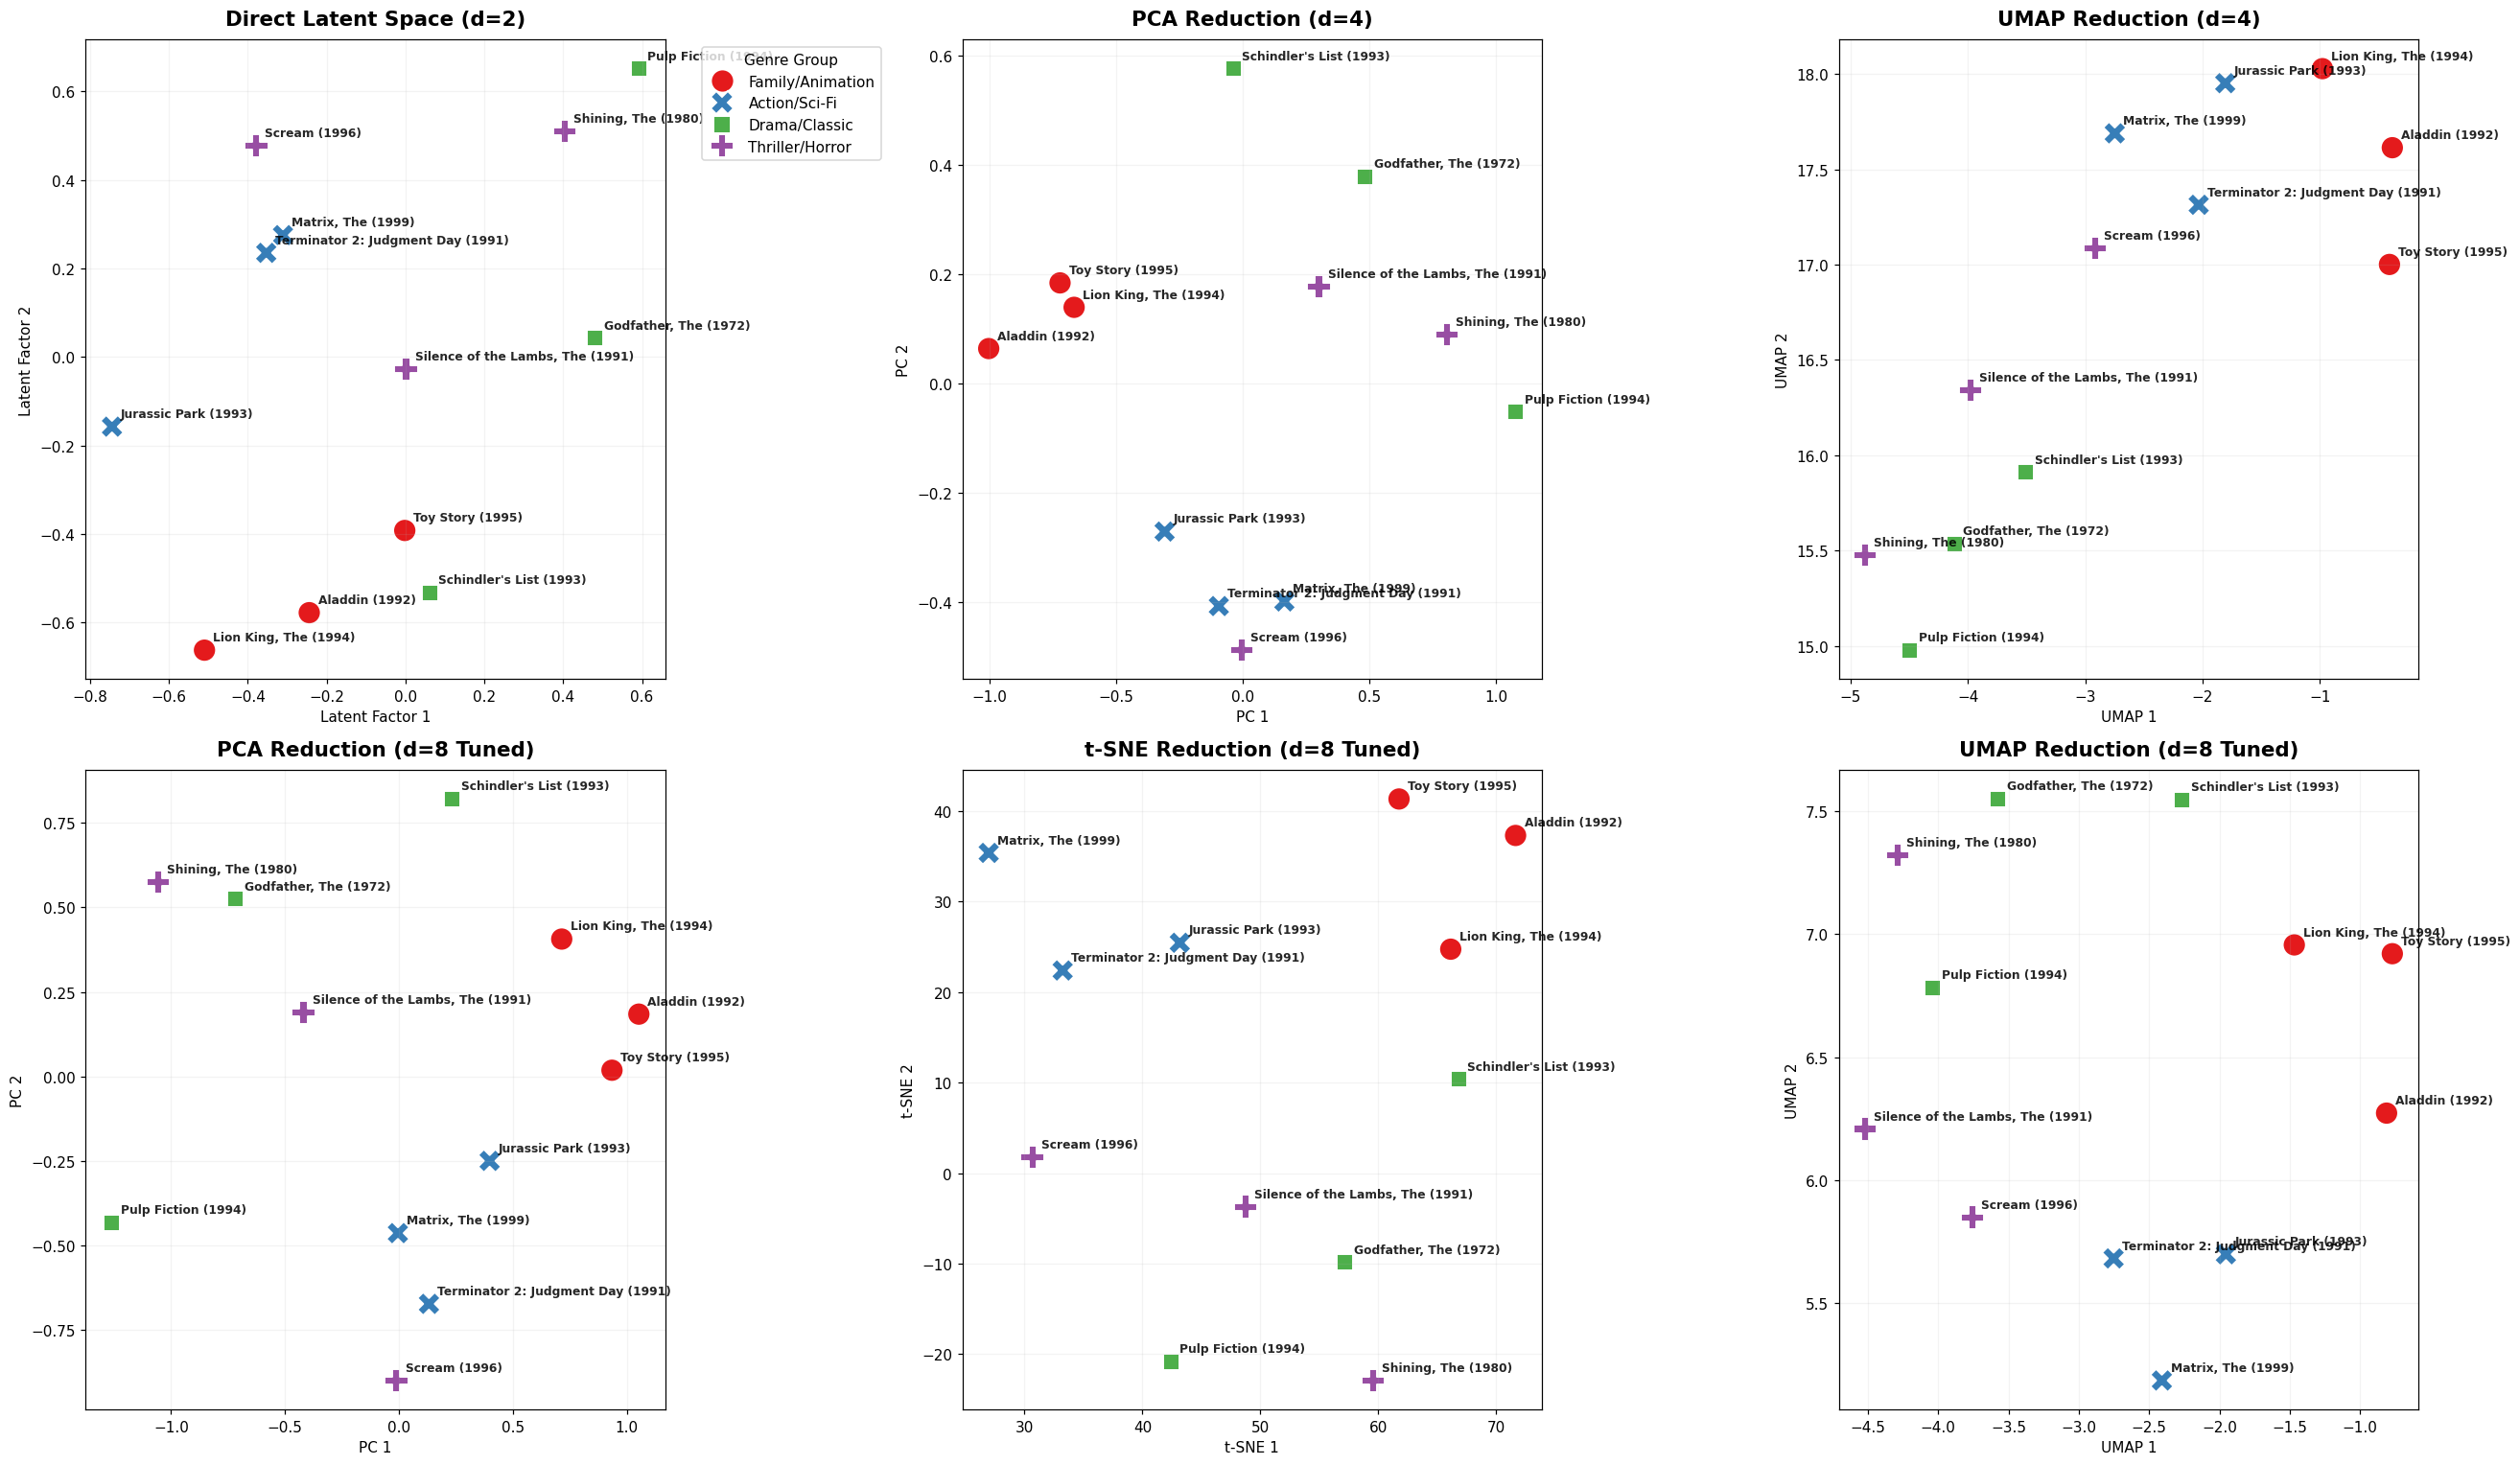

In [92]:
sample_movies = [
    'Toy Story (1995)', 'Aladdin (1992)', 'Lion King, The (1994)',                  # Family/Animation
    'Matrix, The (1999)', 'Jurassic Park (1993)', 'Terminator 2: Judgment Day (1991)', # Action/Sci-Fi
    'Schindler\'s List (1993)', 'Pulp Fiction (1994)', 'Godfather, The (1972)',       # Drama/Classic
    'Scream (1996)', 'Silence of the Lambs, The (1991)', 'Shining, The (1980)'        # Thriller/Horror
]

# Universal title-to-ID mappings validation across ALL THREE models
inv_map = {v: k for k, v in movie_id_to_title.items()}
valid_samples = [
    m for m in sample_movies
    if inv_map.get(m) in model_cmf_2d.item_mapping_
    and inv_map.get(m) in model_cmf.item_mapping_
    and inv_map.get(m) in model_cmf_tunned.item_mapping_
]

def assign_visual_genre(title):
    if title in ['Toy Story (1995)', 'Aladdin (1992)', 'Lion King, The (1994)']: return 'Family/Animation'
    if title in ['Matrix, The (1999)', 'Jurassic Park (1993)', 'Terminator 2: Judgment Day (1991)']: return 'Action/Sci-Fi'
    if title in ['Scream (1996)', 'Silence of the Lambs, The (1991)', 'Shining, The (1980)']: return 'Thriller/Horror'
    return 'Drama/Classic'

# Extract item embedding matrices
item_v_2d = model_cmf_2d.B_
item_v_4d = model_cmf.B_
item_v_8d = model_cmf_tunned.B_

# Map active validation targets back to operational matrix indices
sample_ids = [inv_map.get(m) for m in valid_samples]

# Safely get indices for each model's specific mapping
indices_2d = [list(model_cmf_2d.item_mapping_).index(mid) for mid in sample_ids]
indices_4d = [list(model_cmf.item_mapping_).index(mid) for mid in sample_ids]
indices_8d = [list(model_cmf_tunned.item_mapping_).index(mid) for mid in sample_ids]

# Slice down target sample vectors for localized embedding mapping
vectors_2d_subset = item_v_2d[indices_2d]
vectors_4d_subset = item_v_4d[indices_4d]
vectors_8d_subset = item_v_8d[indices_8d]

# Run projections from the higher dimensional engines (4D and 8d)
# 4D Projections
pca_proj_4d = PCA(n_components=2, random_state=42).fit_transform(vectors_4d_subset)
umap_proj_4d = umap.UMAP(n_neighbors=4, min_dist=0.2, random_state=42).fit_transform(vectors_4d_subset)

# 8d Projections
pca_proj_8d = PCA(n_components=2, random_state=42).fit_transform(vectors_8d_subset)
tsne_proj_8d = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000).fit_transform(vectors_8d_subset)
umap_proj_8d = umap.UMAP(n_neighbors=4, min_dist=0.2, random_state=42).fit_transform(vectors_8d_subset)

# Assemble master dataframe for downstream visual handling
viz_master = pd.DataFrame({
    'Title': valid_samples,
    'Group': [assign_visual_genre(m) for m in valid_samples],
    'Raw_2D_X': vectors_2d_subset[:, 0], 'Raw_2D_Y': vectors_2d_subset[:, 1],
    'PCA_4D_X': pca_proj_4d[:, 0], 'PCA_4D_Y': pca_proj_4d[:, 1],
    'UMAP_4D_X': umap_proj_4d[:, 0], 'UMAP_4D_Y': umap_proj_4d[:, 1],
    'PCA_8d_X': pca_proj_8d[:, 0], 'PCA_8d_Y': pca_proj_8d[:, 1],
    'TSNE_8d_X': tsne_proj_8d[:, 0], 'TSNE_8d_Y': tsne_proj_8d[:, 1],
    'UMAP_8d_X': umap_proj_8d[:, 0], 'UMAP_8d_Y': umap_proj_8d[:, 1]
})

# Plotting 2x3 Grid
fig, axes = plt.subplots(2, 3, figsize=(24, 14), dpi=110)
axes = axes.flatten()
plot_configs = [
    ('Raw_2D_X', 'Raw_2D_Y', 'Direct Latent Space (d=2)', 'Latent Factor 1', 'Latent Factor 2'),
    ('PCA_4D_X', 'PCA_4D_Y', 'PCA Reduction (d=4)', 'PC 1', 'PC 2'),
    ('UMAP_4D_X', 'UMAP_4D_Y', 'UMAP Reduction (d=4)', 'UMAP 1', 'UMAP 2'),
    ('PCA_8d_X', 'PCA_8d_Y', 'PCA Reduction (d=8 Tuned)', 'PC 1', 'PC 2'),
    ('TSNE_8d_X', 'TSNE_8d_Y', 't-SNE Reduction (d=8 Tuned)', 't-SNE 1', 't-SNE 2'),
    ('UMAP_8d_X', 'UMAP_8d_Y', 'UMAP Reduction (d=8 Tuned)', 'UMAP 1', 'UMAP 2')
]
palette_colors = {'Family/Animation': '#E41A1C', 'Action/Sci-Fi': '#377EB8', 'Drama/Classic': '#4DAF4A', 'Thriller/Horror': '#984EA3'}
for ax, (x_col, y_col, title, x_lab, y_lab) in zip(axes, plot_configs):
    sns.scatterplot(ax=ax, data=viz_master, x=x_col, y=y_col, hue='Group', style='Group', s=250, palette=palette_colors, legend=(ax==axes[0]))
    ax.set_title(title, fontsize=14, weight='bold', pad=10)
    ax.set_xlabel(x_lab, fontsize=10)
    ax.set_ylabel(y_lab, fontsize=10)
    ax.grid(True, alpha=0.15)
    if ax == axes[0]:
        ax.legend(title='Genre Group', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Label geometry coordinates
    for _, row in viz_master.iterrows():
        ax.text(row[x_col] + (ax.get_xlim()[1] - ax.get_xlim()[0])*0.015,
                row[y_col] + (ax.get_ylim()[1] - ax.get_ylim()[0])*0.015,
                row['Title'], fontsize=8, alpha=0.85, weight='bold')
plt.tight_layout()
plt.show()

## **Movie Embeddings Visual Analysis**

#### **1. Baseline Latent Space ($d=2$)**

* **Visual Reality:** Complete chaos.
* **Insight:** Two dimensions cannot handle the complexity. Unrelated genres collide blindly—for example, the heavy drama **Schindler's List** is forced right next to the children's animation **Aladdin**.

#### **2. Mid-Tier Model ($d=4$)**

* **PCA:** Stretched and messy. Linear projections fail to decouple the 4D math.
* **UMAP:** **Massive breakthrough.** By switching to non-linear mapping, the genres instantly pull apart into distinct, localized neighborhoods.

#### **3. Tuned Model ($d=8$) — *The Peak Performance***

* **PCA:** Still struggles with central overlap due to rigid linear limitations.
* **t-SNE:** **Outstanding local clustering.** It creates tight, isolated pockets—completely separating the **Animation group** (isolated at the top right) and the **Action group** (isolated on the middle-left) from the rest of the films.
* **UMAP:** **The Cleanest Regional Map.** It provides perfect structural spacing.
    * **Drama/Classic (Green):** Dominating the top layout.
    * **Family/Animation (Red):** Tightly clustered on the right side.
    * **Action/Sci-Fi (Blue):** Firmly locked at the bottom.
    * **Thriller/Horror (Purple):** Perfectly lined up along the far left boundary.

# Model Evaluations

In [93]:
# Define evaluation configurations
k = 10
models = {
    "Base CMF": model_cmf,
    "Tuned CMF": model_cmf_tunned
}

# Identify target user evaluation pool
train_users = set(train_ratings["UserId"].unique())
test_users  = set(test_ratings_raw["UserId"].unique())
common_users = sorted(test_users & train_users)

# Dictionary to hold final aggregated results for comparison
summary_results = []

for model_name, model_obj in models.items():
    print(f"Evaluating {model_name}...")
    rows = []

    for user in common_users:
        # Gather ground-truth historical pools
        train_items = set(train_ratings[train_ratings["UserId"] == user]["ItemId"].values)
        actual_test = set(test_ratings_raw[test_ratings_raw["UserId"] == user]["ItemId"].values)

        # Skip user if they have no test interactions to validate against
        if len(actual_test) == 0:
            continue

        # UNFILTERED METRICS (To measure data leakage)
        unfiltered_recs = model_obj.topN(user=user, n=k)
        top_k_unfiltered = unfiltered_recs[:k]

        seen_hits = len(set(top_k_unfiltered) & train_items)
        overlap_with_train = seen_hits / k

        # FILTERED METRICS (To measure true performance on unseen items)
        # Request an expanded pool so we have enough items left after dropping seen ones
        large_n = k + len(train_items)
        raw_expanded_recs = model_obj.topN(user=user, n=large_n)

        # Filter out historical training items, then slice exactly down to K
        clean_recommendations = [item for item in raw_expanded_recs if item not in train_items][:k]
        top_k_filtered = set(clean_recommendations)

        # Calculate intersections with clean validation test data
        test_hits = len(top_k_filtered & actual_test)

        # Calculate NDCG@k
        # DCG: Add score based on rank position (higher rank = higher score)
        dcg = sum([1 / np.log2(i + 2) for i, item in enumerate(clean_recommendations) if item in actual_test])
        # IDCG: The best possible score if all hits were at the very top
        idcg = sum([1 / np.log2(i + 2) for i in range(min(len(actual_test), k))])
        ndcg_at_key = dcg / idcg if idcg > 0 else 0

        # Metrics calculations
        precision_at_key = test_hits / k
        recall_at_key = test_hits / len(actual_test)

        rows.append({
            "UserId": user,
            "Overlap_with_Train@k": overlap_with_train,
            "SeenHits": seen_hits,
            "Precision@k": precision_at_key,
            "Recall@k": recall_at_key,
            "NDCG@k": ndcg_at_key # Add to user row
        })

    # Convert individual user records to DataFrame for this specific model
    model_eval_df = pd.DataFrame(rows)

    # Store aggregated mean metrics
    summary_results.append({
        "Model": model_name,
        "Overlap_with_Train@k": model_eval_df["Overlap_with_Train@k"].mean(),
        "Avg_SeenHits": model_eval_df["SeenHits"].mean(),
        "Precision@k": model_eval_df["Precision@k"].mean(),
        "Recall@k": model_eval_df["Recall@k"].mean(),
        "NDCG@k": model_eval_df["NDCG@k"].mean()
    })

# Display comparative results
summary_df = pd.DataFrame(summary_results)
print("\n" + "="*30 + " FINAL MODEL COMPARISON " + "="*30)
print(summary_df.to_string(index=False))

Evaluating Base CMF...
Evaluating Tuned CMF...

============================== FINAL MODEL COMPARISON ==============================
    Model  Overlap_with_Train@k  Avg_SeenHits  Precision@k  Recall@k   NDCG@k
 Base CMF              0.010281      0.102815     0.001887  0.000554 0.001415
Tuned CMF              0.232235      2.322351     0.056325  0.020010 0.060324


### **Verdict: Model Can Rank!**

1. **Base CMF (Underfit):** It failed to learn. It couldn't even recommend movies the user had already watched, resulting in near-zero accuracy.
2. **Tunned CMF:**
    1. **It Learns (23.2% Train Overlap):** It successfully maps the "DNA" of what the user already watched.
    2. **It Discovers (5.6% Precision):** When forced to recommend entirely unseen movies, it accurately predicts hits out of a catalog of thousands.
    3. **It Sorts (6% NDCG):** It doesn't just find the right movies; it prioritizes them correctly at the top of the user's screen.

# Recommender System based Pearson Correlation(User-BAsed Aproch)

In [94]:
# Define the New User Profile
new_user_ratings = [
    {'Title': 'Toy Story (1995)', 'Rating': 5.0},
    {'Title': 'Aladdin (1992)', 'Rating': 4.5},
    {'Title': 'Matrix, The (1999)', 'Rating': 2.0},
    {'Title': 'Jurassic Park (1993)', 'Rating': 4.0},
    {'Title': 'Lion King, The (1994)', 'Rating': 4.0}
]
new_user_df = pd.DataFrame(new_user_ratings)

# Find other users who have watched the same movies
# Filter pivot to only include columns (users) that have rated at least one of these movies
common_users_pivot = user_movie_pivot.loc[new_user_df['Title']].dropna(axis=1, how='all')

# Sort users by the count of movies in common
user_common_counts = common_users_pivot.notna().sum().sort_values(ascending=False)

# Take top 100 users and calculate Pearson Similarity
top_100_user_ids = user_common_counts.head(100).index
subset_pivot = common_users_pivot[top_100_user_ids]

def calculate_pearson(new_user_df, subset_pivot):
    similarities = {}
    new_user_series = new_user_df.set_index('Title')['Rating']

    for user_id in subset_pivot.columns:
        user_ratings = subset_pivot[user_id]
        # Pearson correlation requires overlapping non-NaN values
        corr = new_user_series.corr(user_ratings, method='pearson')
        similarities[user_id] = corr if not np.isnan(corr) else 0.0

    return pd.Series(similarities, name='Similarity')

user_similarities = calculate_pearson(new_user_df, subset_pivot)

# Get top 10 users and calculate Weighted Ratings
top_10_users = user_similarities.sort_values(ascending=False).head(10)

# Get all movies rated by these top 10 similar users
similar_users_ratings = user_movie_pivot[top_10_users.index]

# Calculate Weighted Ratings
# Multiply every rating by the user's similarity index
weighted_ratings_matrix = similar_users_ratings.multiply(top_10_users, axis=1)

# Calculate recommendation scores
# Sum of Weighted Ratings / Sum of Similarity Indices for users who rated the movie
sum_weighted = weighted_ratings_matrix.sum(axis=1)
# We only sum similarities of users who actually provided a rating for that specific movie
sum_similarity = (similar_users_ratings.notna().astype(int).multiply(top_10_users, axis=1)).sum(axis=1)

recommendation_df = (sum_weighted / sum_similarity).to_frame(name='Recommendation_Score')

# Filter out movies the new user has already watched
recommendation_df = recommendation_df.drop(index=new_user_df['Title'], errors='ignore')

# Final Recommendations (Focusing on highest scores, e.g. 5.0)
print("Top 10 User-Based Pearson Recommendations")

recommendation_df.sort_values(by='Recommendation_Score', ascending=False).head()

Top 10 User-Based Pearson Recommendations


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Recommendation_Score
Title,
"Wings of the Dove, The (1997)",5.0
"Children of Heaven, The (Bacheha-Ye Aseman) (1997)",5.0
12 Angry Men (1957),5.0
Charade (1963),5.0
"Color of Paradise, The (Rang-e Khoda) (1999)",5.0


# Final Interactive Rec-sys

In [95]:
# 1. Shared Selection Widget
# We use the intersection of all available indices to ensure the dropdown works for all models
all_titles = sorted(list(set(user_movie_pivot.index) &
                         set(user_movie_pivot_im.index) &
                         set(item_embeddings_df.index)))

movie_dropdown = widgets.Dropdown(options=all_titles, value='Toy Story 2 (1999)', description='Movie:')
recs_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Count:')
output_area = widgets.Output()

def update_all_recommendations(change):
    with output_area:
        clear_output(wait=True)
        target = movie_dropdown.value
        n = recs_slider.value
        print(f"Generating recommendations for: '{target}' (Top {n})\n" + "="*70)

        # PEARSON
        print("\n[METHOD 1: PEARSON CORRELATION]")
        print(recommend_movies_pearson(target, pearson_matrix, user_movie_pivot, shared_user_matrix, n).to_string(index=False))

        # KNN
        print("\n" + "="*70 + "\n[METHOD 2: KNN COSINE SIMILARITY]")
        print(recommend_knn_cosine(target, user_movie_pivot_im, model_knn, n).to_string(index=False))

        # CMF (BASE & TUNED)
        print("\n" + "="*70 + "\n[METHOD 3: CMF EMBEDDINGS (BASE vs TUNED)]")
        print(recommend_items_cmf(target, item_embeddings_df, n).to_string(index=False))
        print("\n--- TUNED CMF ---")
        print(recommend_items_cmf(target, item_embeddings_tunned_df, n).to_string(index=False))

# 2. Attach listeners
movie_dropdown.observe(update_all_recommendations, names='value')
recs_slider.observe(update_all_recommendations, names='value')

# 3. Initial Display
display(widgets.VBox([movie_dropdown, recs_slider]), output_area)
update_all_recommendations(None)

Output()

# Results Interpretation

Here is a clear, comparative analysis of how four models performed for **Toy Story 2 (1999)** (A block-buster movie).

### **The Verdict**

**Pearson Correlation** performed the best overall, delivering 5 out of 5 highly relevant animated family films. **Tuned CMF** successfully fixed the failure of the Base CMF, proving hyperparameter tuning worked.

---

### **Model-by-Model Breakdown**

**1. Pearson Correlation (The Winner)**

* **Results:** *Toy Story, Hercules, A Bug's Life, The Rescuers, Aladdin*
* **Analysis:** Outstanding. Every single recommendation is a 90s/classic animated family movie. Pearson excels here because it adjusts for user grading scales (optimist vs. harsh critic) by mean-centering the data, finding people with genuinely identical taste profiles.

**2. Cosine Similarity (kNN)**

* **Results:** *Toy Story, A Bug's Life, Babe, Groundhog Day, Shakespeare in Love*
* **Analysis:** Good, but suffering from **Popularity Bias**. It nailed the top two, but then drifted into random, highly-rated 90s blockbusters. Because raw cosine similarity doesn't adjust for user rating volume, it tends to just recommend movies that *everyone* liked during that era.

**3. Base CMF Model (The Failure)**

* **Results:** *Anchors Aweigh, Bug's Life, In Old California...*
* **Analysis:** Complete collapse. With the exception of *A Bug's Life*, it recommended obscure movies from the 1930s/40s.

**4. Tuned CMF Model (The Recovery)**

* **Results:** *Toy Story, Bug's Life, Aladdin, Hear My Song, Son of the Sheik*
* **Analysis:** A massive improvement over the Base model. The top 3 are spot-on (*Toy Story, Bug's Life, Aladdin*), proving that expanding to `d=8` and tuning the regularization allowed the model to separate "Animation" from the rest of the cluster.
* *Note:* The bottom two are still slightly obscure. Matrix Factorization is known for surfacing "Long Tail" (niche) items, but it might also indicate the model could use slightly more data to fully stabilize the bottom ranks.

---

### Takeaways

For ultra-popular movies with massive data footprints, simple correlation often feels more "human" and accurate. But for the remaining 99% of the catalog—the obscure movies, the brand new users, and the scaling required to serve millions of requests per second—Matrix Factorization is the engine that actually keeps the system running.

In [96]:
# Get rating counts for all movies
rating_counts = user_movie_pivot.sum(axis=1) # or equivalent count if pivot is binary

# Filter for movies that exist in index but have low rating counts
niche_candidates = rating_counts[(rating_counts > 20) & (rating_counts < 150)].index.tolist()

for target in niche_candidates[:3]:
    print(f"\n--- Comparative Analysis: {target} ---")
    # 1. Pearson
    print("PEARSON:\n", recommend_movies_pearson(target, pearson_matrix, user_movie_pivot, shared_user_matrix, top_n=5).to_string(index=False))
    # 2. kNN
    print("\nKNN:\n", recommend_knn_cosine(target, user_movie_pivot_im, model_knn, top_n=5).to_string(index=False))
    # 3. Tuned CMF
    print("\nMF (Tuned):\n", recommend_items_cmf(target, item_embeddings_tunned_df, top_n=5).to_string(index=False))


--- Comparative Analysis: $1,000,000 Duck (1971) ---
------------------------------------------------------------
TARGET MOVIE: $1,000,000 Duck (1971) (Total Ratings Count: 37)
DYNAMIC FILTER: Eliminating records with less than 5 co-raters.
------------------------------------------------------------
PEARSON:
                       Title  Pearson_Correlation
Operation Dumbo Drop (1995)             0.930244
    Fierce Creatures (1997)             0.930160
       Baby Geniuses (1999)             0.911666
   Evening Star, The (1996)             0.902064
  Secret Garden, The (1993)             0.890322

KNN:
                                  Title  Cosine_Similarity
Computer Wore Tennis Shoes, The (1970)           0.308903
             Blackbeard's Ghost (1968)           0.301220
        Barefoot Executive, The (1971)           0.300920
                 That Darn Cat! (1965)           0.275245
                     Candleshoe (1977)           0.271330

MF (Tuned):
                         

### **Result Analysis: 3 Ninjas**

* **Pearson & kNN (The "Sparsity & Genre" Traps):** * **Pearson** completely overfit, hallucinating a perfect `1.0` correlation with the gritty R-rated drama *Cop Land* due to a single overlapping user.
* **kNN** got lost in data sparsity, yielding a bizarre, fragmented list that puts *Barney's Great Adventure* right next to urban action-dramas like *Penitentiary II*.

* **Tuned CMF:** It successfully bypassed the superficial "kids' movie" label, matching *3 Ninjas* with **Power 98 (1995)**, and **I Still Know What You Did Last Summer (1998)**.

**It found the "90s Mid-Budget Genre."** Even though the movie is marketed for children, Matrix Factorization model recognized the structural footprint of the film—its specific mid-to-late 90s release window, low-to-mid budget technical production, and B-movie action pacing. It correctly identified that *3 Ninjas* shares more underlying latent DNA with 90s electronic thrillers and teen suspense films than it does with *Barney*.

---

### **Other Movies**

* **$1,000,000 Duck:** **kNN** actually won here, perfectly clustering 1960s/70s live-action Disney classics (*The Computer Wore Tennis Shoes*, *Blackbeard's Ghost*). **Tuned CMF** held its ground by keeping the core match (*The Barefoot Executive*) while blending in era-appropriate 90s light family-comedies.
  
* **'Til There Was You:** **Pearson** fell into an obvious sparse-data trap with a `0.999` correlation on *Apple Dumpling Gang*. **kNN** beautifully locked onto mid-90s romantic comedies (*Picture Perfect*, *If Lucy Fell*), while **Tuned CMF** abstracted the space further, mapping it to highly stylized late-90s character dramas (*The Newton Boys*, *One Night Stand*).

# **The Practical Lesson**

For building a world-class recommendation engine:
1. **Use Pearson** It is great for popular movies, but it "breaks" and gives random results when data is thin.
2. **Use kNN** When want to give the user "more of the same" (e.g., "You liked this comedy, here are 5 more comedies").
3. **Use MF** When want to **surprise the user** with high-quality discoveries that feel different but "fit" the user's hidden preferences.

# Questionnaire

## 1. Users of which age group have watched and rated the most number of movies?

Ans: 25-34

In [97]:
users.Age_Label.value_counts().head(1)

,count
Age_Label,
25-34,2096


## 2. Users belonging to which profession have watched and rated the most movies?

Ans: `college/grad student` users are the highest, but if looking for occupation i.e. having a job then `executive/managerial`

In [98]:
users.Occupation_Label.value_counts().head(3)

,count
Occupation_Label,
college/grad student,759
other,711
executive/managerial,679


## 3. Most of the users in our dataset who’ve rated the movies are Male. (T/F)

Ans: True

In [99]:
ratings['UserID'].value_counts().reset_index().sort_values(by='UserID', ascending=True).merge(users, on='UserID', how='left')[['UserID', 'count', 'Gender']].groupby('Gender').agg({'count': 'sum'}).sort_values(by='count', ascending=False)

,count
Gender,
M,753769
F,246440


## 4. Most of the movies present in our dataset were released in which decade? (a.70s b. 90s c. 50s d.80s)

Ans: 1990-1999 i.e. b. 90s

In [100]:
movies['decade range'] = movies['Release Year'].apply(
    lambda y: f"{int(y // 10 * 10)}-{int(y // 10 * 10 + 9)}" if not pd.isna(y) else "Unknown"
)
movies['decade range'].value_counts().head(1)

,count
decade range,
1990-1999,3747


## 5. The movie with maximum no. of ratings is ___.

Ans: American Beauty (1999)

In [101]:
movies[movies['MovieID'] == ratings.groupby('MovieID')['Rating'].count().sort_values(ascending=False).head(1).index[0]].Title.values[0]

'American Beauty (1999)'

## 6. Name the top 3 movies similar to ‘Liar Liar’ on the item-based approach.

Ans.

- [METHOD 1: PEARSON CORRELATION]

```
                                Title  Pearson_Correlation
                      Spy Hard (1996)             0.500659
Ace Ventura: When Nature Calls (1995)             0.497764
            Dead Man on Campus (1998)             0.475883
```

- [METHOD 2: KNN COSINE SIMILARITY]

```
                            Title  Cosine_Similarity
            Mrs. Doubtfire (1993)           0.557067
Ace Ventura: Pet Detective (1994)           0.516861
             Dumb & Dumber (1994)           0.512585
```

- [METHOD 3: CMF EMBEDDINGS (BASE vs TUNED)]

```
--- BASE CMF ---
                     Title  CMF_Similarity
     Grumpy Old Men (1993)        0.993555
Weekend at Bernie's (1989)        0.986315
    Lethal Weapon 2 (1989)        0.985524


--- TUNED CMF ---
                 Title  CMF_Similarity
   Multiplicity (1996)        0.875609
Karate Kid, The (1984)        0.840932
        Mr. Mom (1983)        0.834737
```


## 7. On the basis of approach, Collaborative Filtering methods can be classified into ___-based and ___-based.

Ans.

- Memory-based e.g. Pearson correlation, Nearest neighbour using cosine similarity
- Model-based e.g. Matrix Factorization

## 8. Pearson Correlation ranges between ___ to ___ whereas, Cosine Similarity belongs to the interval between ___ to ___.

Ans: Both ranges are -1 to 1

## 9. Mention the RMSE and MAPE that you got while evaluating the Matrix Factorization model.

Ans:

- Before tunning (d=4)

```
[WARM-START] RMSE (Collaborative Path) : 0.9016
[WARM-START] MAPE (Collaborative Path) : 28.09%
-------------------------------------------------------
[COLD-START] RMSE (Metadata Path)      : 1.1320
[COLD-START] MAPE (Metadata Path)      : 42.47%
```

- After tunning (d=8)

```
[WARM-START] RMSE (Collaborative Path) : 0.8840
[WARM-START] MAPE (Collaborative Path) : 27.62%
------------------------------------------------------------
[COLD-START] RMSE (Metadata Path)      : 1.0385
[COLD-START] MAPE (Metadata Path)      : 39.41%
```

## 10. Give the sparse ‘row’ matrix representation for the following dense matrix -
```
[[1 0]
[3 7]]
```

In [102]:
dense_matrix = np.array([
    [1, 0],
    [3, 7]
])

# Convert to Compressed Sparse Row (CSR) matrix representation
sparse_row_matrix = csr_matrix(dense_matrix)
print(sparse_row_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (2, 2)>
  Coords	Values
  (0, 0)	1
  (1, 0)	3
  (1, 1)	7
